In [ ]:
import sys
sys.version

'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'

[x(t-9), x(t-8), ..., x(t)]について状態を引き継ぎながら、12N次元のノードのリザバー内で非線形発展させ、x(t+1)を予測する。なお、12N次元への写像はランダム行列Winによって射影される

In [ ]:
import numpy as np
from typing import Tuple, Optional

def simulate_and_fit_one_pass_window10(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U10: np.ndarray,                 # shape (T, 10)  入力窓列: [x(t-9)..x(t)]
    Y: np.ndarray,                   # shape (T,)     教師: x(t)
    *,
    ridge: float = 1e-2,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",         # "pm" or "plus"
    input_mode: str = "scale",       # "scale" or "replace"
    Win: Optional[np.ndarray] = None,# shape (10, M)  入力マスク（固定）。Noneなら生成
    Win_scale: float = 1.0,
    x0: Optional[np.ndarray] = None, # shape (M,) 初期状態（無励起確率）
    carry_state: bool = True,        # True: 時刻に沿って状態を引き継ぐ
) -> Tuple[np.ndarray, float, np.ndarray, np.ndarray, np.ndarray]:
    """
    出力:
      w: (M,)        Wout
      b: float       bias
      y_hat: (T,)    予測
      S: (T,M)       状態列（out_prob）
      xT: (M,)       最終状態（無励起確率）
    """
    # -------------------------
    # 形チェック
    # -------------------------
    U10 = np.asarray(U10, dtype=float)
    Y = np.asarray(Y, dtype=float).reshape(-1)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError(f"U10 must be (T,10). got {U10.shape}")
    T = U10.shape[0]
    if Y.size != T:
        raise ValueError(f"Y must be length T={T}. got {Y.size}")

    M = 12 * N
    rng = np.random.default_rng(seed)

    # 入力マスク Win: (10,M)
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(10, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, dtype=float)
        if Win.shape != (10, M):
            raise ValueError(f"Win must be shape (10,{M}). got {Win.shape}")

    # 初期状態 x（無励起確率 0..1）
    if x0 is None:
        x_state = np.zeros(M, dtype=float)
    else:
        x_state = np.asarray(x0, dtype=float).reshape(-1).copy()
        if x_state.size != M:
            raise ValueError(f"x0 must be length {M}. got {x_state.size}")
        x_state = np.clip(x_state, 0.0, 1.0)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    # -------------------------
    # 時系列を流して状態列 S を作る
    # -------------------------
    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # (A) 10次元窓 → M次元入力 u_vec
        # u_vec[j] = sum_i U10[t,i] * Win[i,j]
        u_vec = U10[t] @ Win  # (M,)

        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # (B) ① 確率注入（無励起確率 x_state を使う）
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # (C) ②〜⑤ 干渉ネットワーク
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        # (D) ⑦ 合成
        fin = (wnet + u_vec) / sqrt2

        # (E) ⑧ 非線形：検出確率 out_prob を状態とする（サンプリングしない）
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)

        # log(p0_like) = log(coef) - |fin|^2 + tanh(r) * fin^2
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        # 数値安定化：exp の実部をクリップ（±700程度）
        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)  # 上限は用途により 50 などでも十分
        log_p0_safe = re + 1j * im

        p0_like = np.exp(log_p0_safe)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)


        S[t] = out_prob

        # (F) 状態更新（無励起確率として次へ）
        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)
        # carry_state=False の場合は毎回同じ x_state（x0固定）で独立写像

    xT = x_state.copy()

    # -------------------------
    # Wout を ridge で学習： y_hat = S @ w + b
    # -------------------------
    X = np.hstack([S, np.ones((T, 1))])  # (T, M+1)
    Reg = np.diag(np.append(np.full(M, ridge), 0.0))  # biasは正則化しない
    theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)   # (M+1,)
    w = theta[:M]
    b = float(theta[M])

    y_hat = S @ w + b

    return w, b, y_hat, S, xT

In [ ]:
def make_window10_dataset(x_series: np.ndarray, start_t: int, T: int):
    """
    入力:  U10[k] = [x(t-9)..x(t)],  t = start_t + k
    教師:  Y[k]   = x(t+1)
    """
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 9:
        raise ValueError("start_t must be >= 9")
    if start_t + T + 1 > len(x):
        raise ValueError("range out of x_series (need t+1)")

    U10 = np.vstack([x[t-9:t+1] for t in range(start_t, start_t + T)])  # (T,10)
    Y = x[start_t + 1 : start_t + T + 1]                                # (T,)
    return U10, Y

def lorenz_f(XYZ):
    X, Y, Z = XYZ
    return np.array([10.0*(Y - X), (X*(28.0 - Z) - Y), (X * Y - 8.0/3*Z)])

def lorenz_x_RK(t):
    XYZ = np.array([0.5, 0.1, 0.2])
    dt = 0.01
    Xset = [XYZ[0]]
    for _ in range(t + 1000):  # burn-in 1000
        k1 = lorenz_f(XYZ)
        k2 = lorenz_f(XYZ + dt/2 * k1)
        k3 = lorenz_f(XYZ + dt/2 * k2)
        k4 = lorenz_f(XYZ + dt * k3)
        XYZ += dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        Xset.append(XYZ[0])
    return np.array(Xset[1000:])  # X(t) 連続値


import matplotlib.pyplot as plt
import numpy as np

def plot_timeseries_compare(y_true, y_pred, *, start=0, length=300, title=None):
    """
    y_true, y_pred: 1D arrays (same length)
    start: プロット開始インデックス
    length: 表示点数
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    assert y_true.shape == y_pred.shape

    end = min(start + length, y_true.size)
    t = np.arange(start, end)

    plt.figure(figsize=(12, 4))
    plt.plot(t, y_true[start:end], label="True", lw=2)
    plt.plot(t, y_pred[start:end], label="Predicted", lw=1.5, alpha=0.8)
    plt.xlabel("time index")
    plt.ylabel("x")
    plt.legend()
    if title is not None:
        plt.title(title)
    plt.tight_layout()
    plt.show()

**Lorenz-63予測**

MSE= 38.095701474404024 Corr= 0.6114623640984156


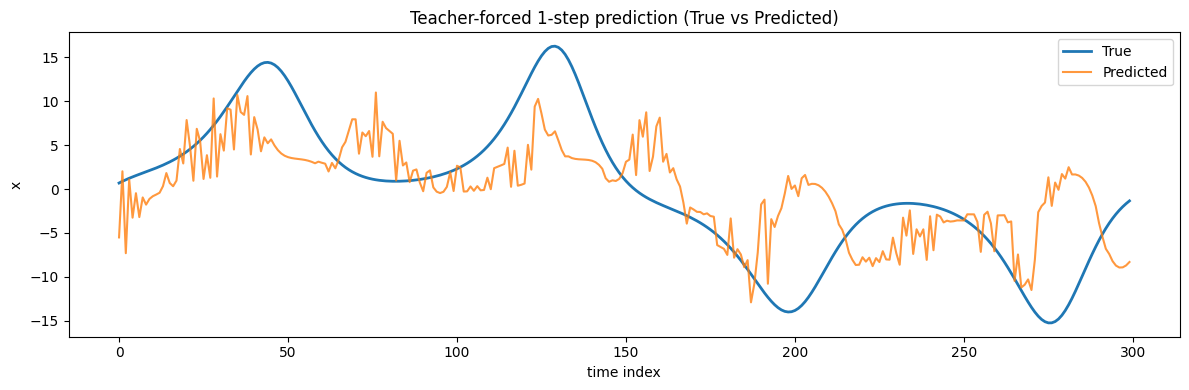

In [ ]:
# Lorenz
x_series = lorenz_x_RK(6000)

# データ（例：t=1000から1000ステップ分）
U10, Y = make_window10_dataset(x_series, start_t=1000, T=1000)

# 学習＋予測
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=1,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 45.60057369128992 Corr= 0.5005411993185828


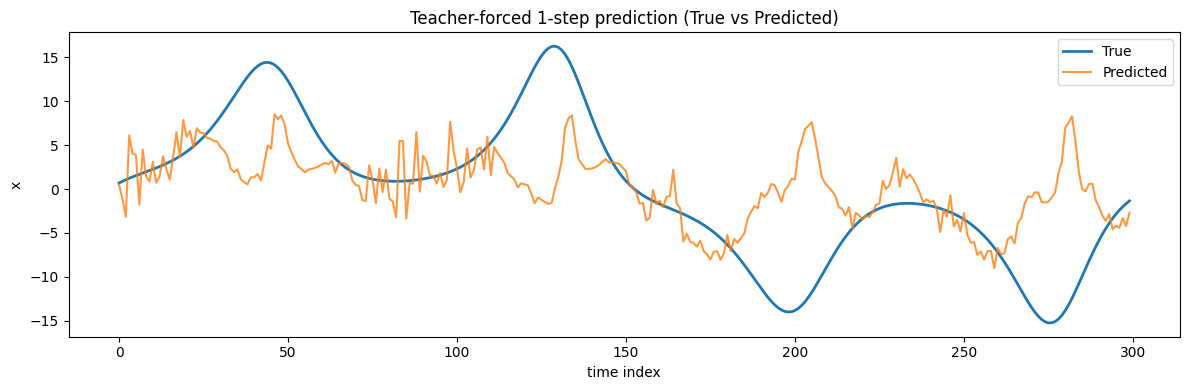

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=2,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 17.85337223345052 Corr= 0.8405799880813433


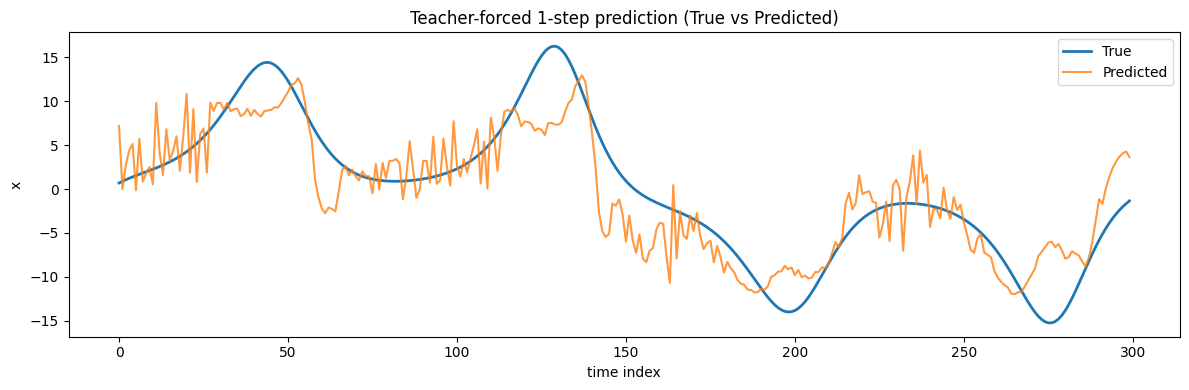

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=3,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 31.534493893013522 Corr= 0.6940616626461399


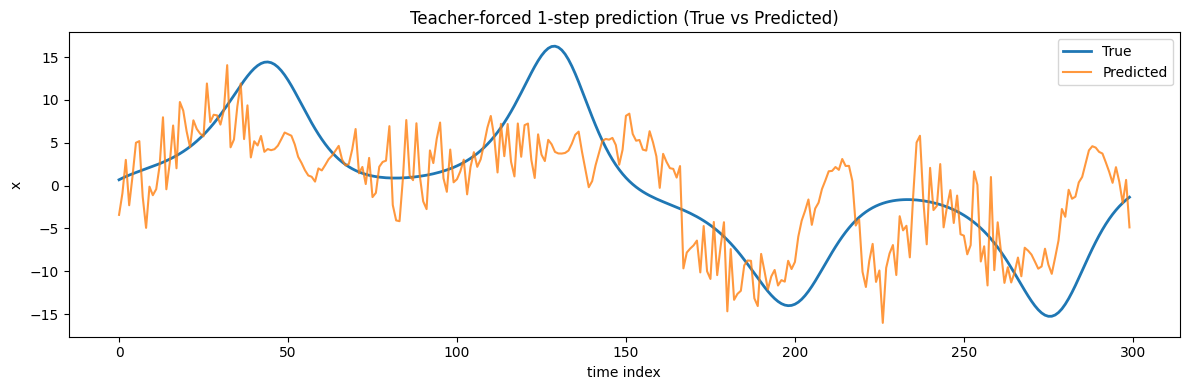

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=4,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 0.33149109769156004 Corr= 0.997272318998409


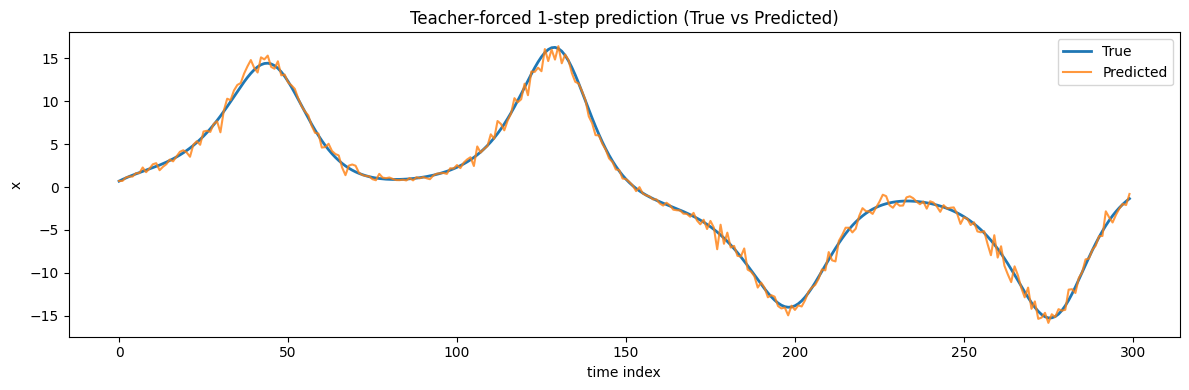

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=50,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 0.01932618224844604 Corr= 0.9998412107181331


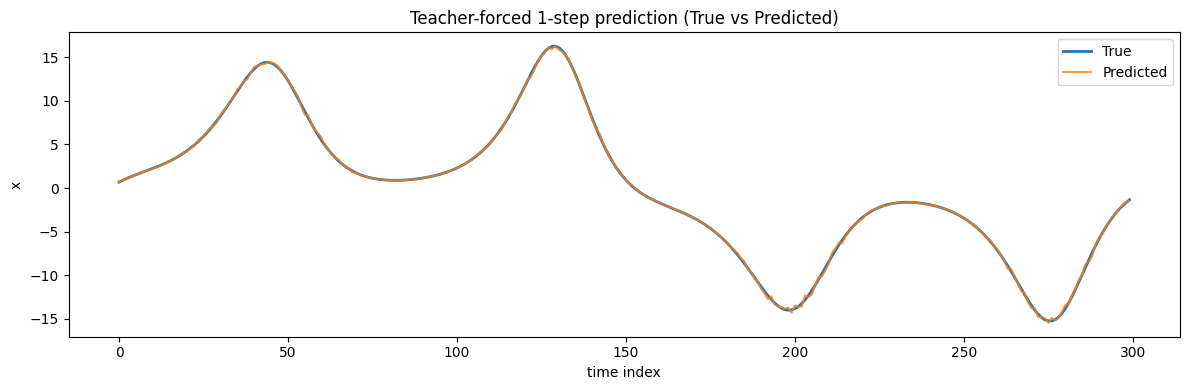

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 0.021373138535813054 Corr= 0.9998244118014642


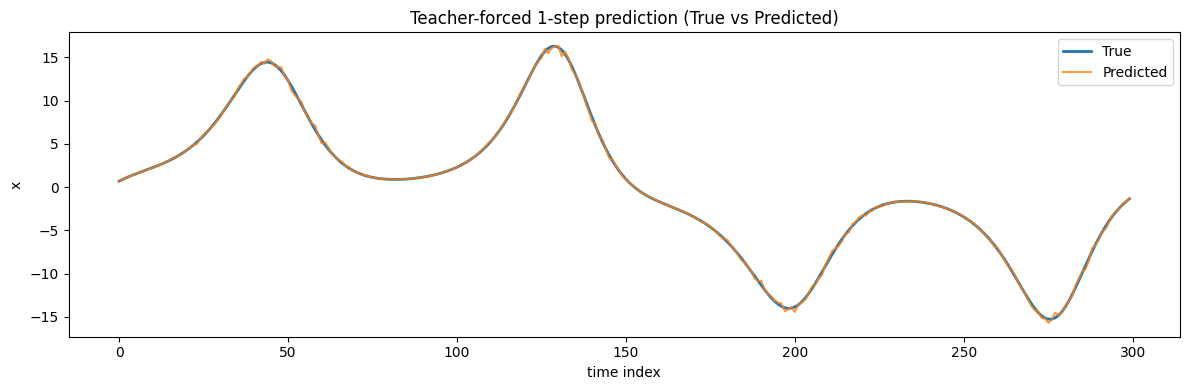

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=2,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 0.015855797699190943 Corr= 0.9998697235744313


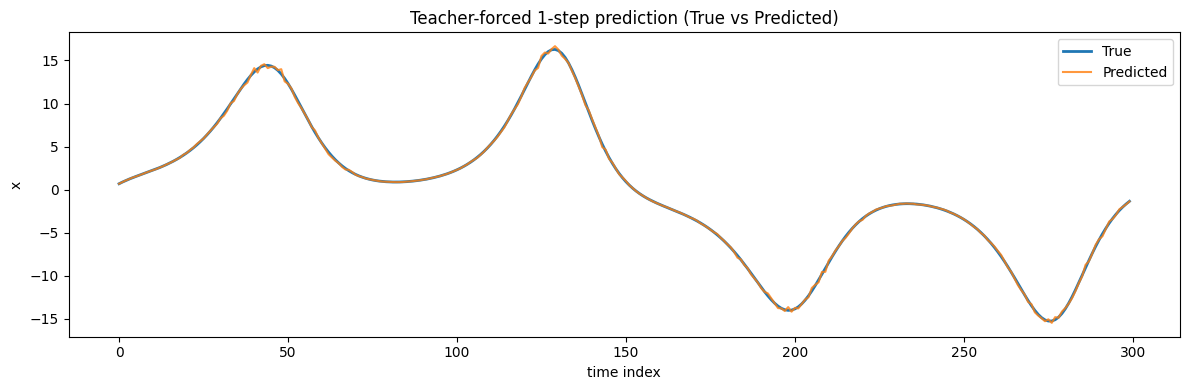

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=48,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 0.015855797699190943 Corr= 0.9998697235744313


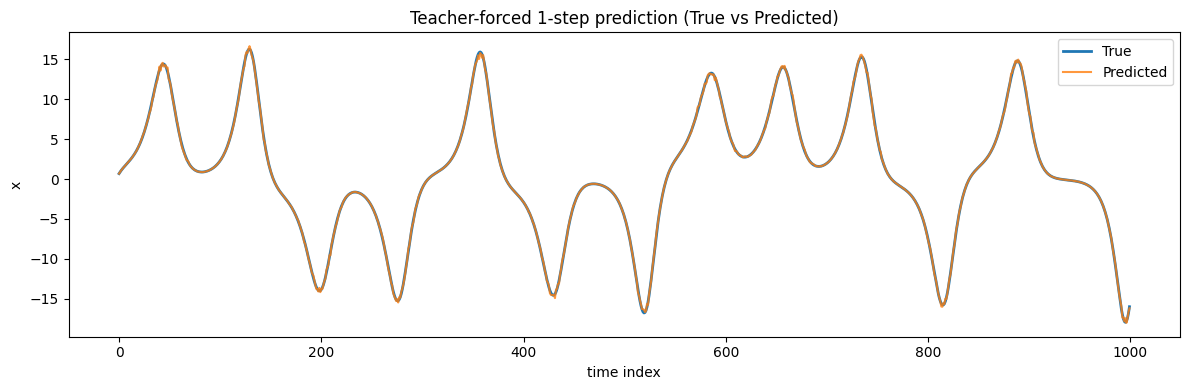

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=48,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=3000,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

**古典的なリザバー（tanh）での1ステップ予測との比較**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# -------------------------
# データセット: 入力 U10=[x(t-9)..x(t)], 教師 Y=x(t+1)
# -------------------------
def make_window10_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 9:
        raise ValueError("start_t must be >= 9")
    if start_t + T + 1 > len(x):
        raise ValueError("range out of x_series (need t+1)")
    U10 = np.vstack([x[t-9:t+1] for t in range(start_t, start_t + T)])  # (T,10)
    Y = x[start_t + 1 : start_t + T + 1]                                # (T,)
    return U10, Y

# -------------------------
# 共通: ridge readout（bias付き、biasは正則化しない）
# -------------------------
def fit_readout_ridge(S: np.ndarray, Y: np.ndarray, ridge: float = 1e-2) -> Tuple[np.ndarray, float]:
    S = np.asarray(S, float)
    Y = np.asarray(Y, float).reshape(-1)
    T, M = S.shape
    if Y.size != T:
        raise ValueError("S and Y length mismatch")
    X = np.hstack([S, np.ones((T, 1))])  # (T, M+1)
    Reg = np.diag(np.append(np.full(M, ridge), 0.0))  # biasは正則化しない
    theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)
    w = theta[:M]
    b = float(theta[M])
    return w, b

def predict_readout(S: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    return np.asarray(S, float) @ np.asarray(w, float) + float(b)

def mse_corr(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    y_true = np.asarray(y_true, float).reshape(-1)
    y_pred = np.asarray(y_pred, float).reshape(-1)
    mse = float(np.mean((y_true - y_pred) ** 2))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    return mse, corr

def plot_true_vs_pred(y_true, y_pred, title=""):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label="True", lw=2)
    plt.plot(y_pred, label="Predicted", lw=1.5, alpha=0.85)
    plt.title(title)
    plt.xlabel("time index")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# (A) あなたの QRC: simulate_and_fit_one_pass_window10 の「⑧は安全版」にしておく
# =========================================================
def simulate_qrc_states_outprob(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U10: np.ndarray,           # (T,10)
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",   # "pm" or "plus"
    input_mode: str = "scale", # "scale" or "replace"
    Win: Optional[np.ndarray] = None,     # (10,M)
    Win_scale: float = 1.0,
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      S: (T,M) out_prob（検出確率）状態列
      xT: (M,) 最終状態（無励起確率）
    """
    U10 = np.asarray(U10, float)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError("U10 must be (T,10)")
    T = U10.shape[0]
    M = 12 * N
    rng = np.random.default_rng(seed)

    # 入力マスク (10,M)
    if Win is None:
        # 過度に大きくならないよう 1/sqrt(10) で軽く正規化
        Win = rng.uniform(-1.0, 1.0, size=(10, M)) * (float(Win_scale) / np.sqrt(10.0))
    else:
        Win = np.asarray(Win, float)
        if Win.shape != (10, M):
            raise ValueError(f"Win must be (10,{M})")

    # 状態（無励起確率）
    x_state = np.zeros(M, dtype=float)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # 10次元窓 → M次元入力
        u_vec = U10[t] @ Win  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ① 確率注入
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # ②〜⑤ ネットワーク
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / sqrt2

        # ⑧ 非線形（安全版）：exp をまとめ、実部をクリップ
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        S[t] = out_prob

        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    return S, x_state


# =========================================================
# (B) 決定論的 ESN (tanh) ：同じ M=12N、入力10次元
# =========================================================
def simulate_esn_states_tanh(
    M: int,
    U10: np.ndarray,  # (T,10)
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    標準的 ESN:
      x_{t+1} = (1-leak)*x_t + leak*tanh( Wres x_t + Win u_t + b )
    Returns:
      S: (T,M) 状態列
      params: Wres, Win, b
    """
    U10 = np.asarray(U10, float)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError("U10 must be (T,10)")
    T = U10.shape[0]
    rng = np.random.default_rng(seed)

    # Win: (10,M)
    Win = rng.uniform(-1.0, 1.0, size=(10, M)) * float(input_scale)

    # Wres: (M,M) を作ってスペクトル半径調整
    Wres = rng.normal(0.0, 1.0, size=(M, M)) / np.sqrt(M)

    # スペクトル半径調整（最大固有値の絶対値で正規化）
    eigvals = np.linalg.eigvals(Wres)
    sr = np.max(np.abs(eigvals)) + 1e-12
    Wres = Wres * (float(spectral_radius) / sr)

    b = rng.uniform(-1.0, 1.0, size=M) * float(bias_scale)

    x = np.zeros(M, dtype=float)
    S = np.empty((T, M), dtype=float)

    for t in range(T):
        pre = x @ Wres + U10[t] @ Win + b
        x_new = np.tanh(pre)
        x = (1.0 - leak_rate) * x + leak_rate * x_new
        S[t] = x

    params = {"Wres": Wres, "Win": Win, "b": b}
    return S, params


# =========================================================
# 実験: QRC vs ESN を同じ M で比較してプロット
# =========================================================
def compare_qrc_vs_esn(
    x_series: np.ndarray,
    *,
    N: int = 100,
    start_t: int = 1000,
    T: int = 1000,
    seed: int = 43,
    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    ridge: float = 1e-2,
    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    U10, Y = make_window10_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    # --- QRC
    S_qrc, _ = simulate_qrc_states_outprob(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U10=U10,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
    )
    wq, bq = fit_readout_ridge(S_qrc, Y, ridge=ridge)
    Yhat_qrc = predict_readout(S_qrc, wq, bq)
    mse_qrc, corr_qrc = mse_corr(Y, Yhat_qrc)

    # --- ESN
    S_esn, _ = simulate_esn_states_tanh(
        M=M, U10=U10,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn, Y, ridge=ridge)
    Yhat_esn = predict_readout(S_esn, we, be)
    mse_esn, corr_esn = mse_corr(Y, Yhat_esn)

    print(f"[QRC] M={M}  MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN] M={M}  MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")

    plot_true_vs_pred(Y, Yhat_qrc, title=f"QRC (out_prob) Teacher-forced 1-step | N={N}, M={M}")
    plot_true_vs_pred(Y, Yhat_esn, title=f"ESN (tanh) Teacher-forced 1-step | M={M}")

    return {
        "Y": Y,
        "Yhat_qrc": Yhat_qrc,
        "Yhat_esn": Yhat_esn,
        "metrics": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        }
    }

[QRC] M=1200  MSE=0.000121  Corr=0.999999
[ESN] M=1200  MSE=0.000009  Corr=1.000000


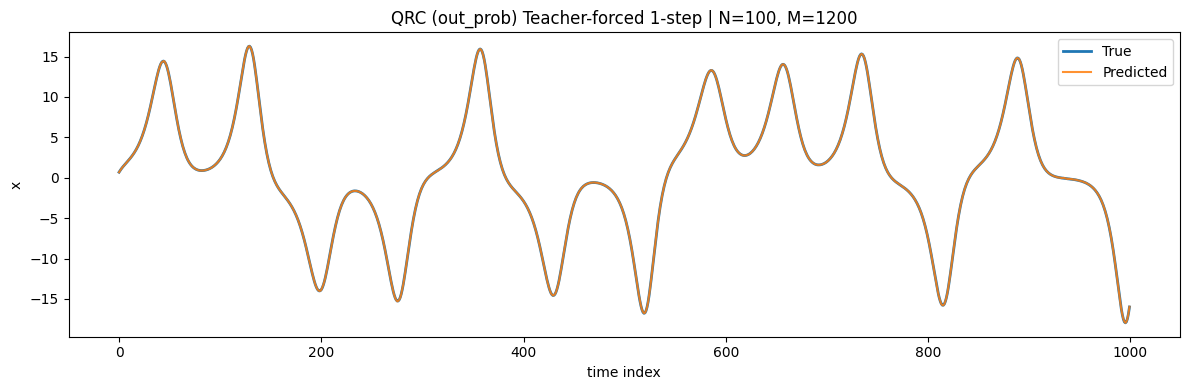

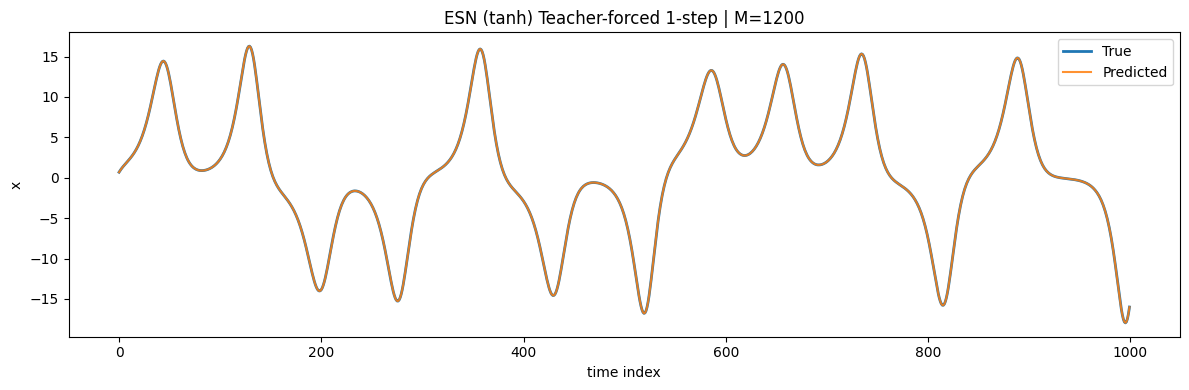

In [ ]:
x_series = lorenz_x_RK(6000)

res = compare_qrc_vs_esn(
    x_series,
    N=100,
    start_t=1000,
    T=1000,
    seed=43,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

今考えているQRCでは同条件下での古典リザバーを上回ることができなさそう

→ノイズを入れて分散項（2次モーメント）を入れたらどうなるか？

→検出フリップを入れたらどうなるのか？

を調べる


In [ ]:
import numpy as np
from typing import Tuple, Optional

def simulate_qrc_states_sampled01(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U10: np.ndarray,           # (T,10)
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",   # "pm" or "plus"
    input_mode: str = "scale", # "scale" or "replace"
    Win: Optional[np.ndarray] = None,  # (10,M)
    Win_scale: float = 1.0,
    carry_state: bool = True,
    # --- sampling / noise ---
    shots: int = 10,           # 1時刻あたりの試行回数（平均化）
    flip_p: float = 0.10,      # フリップ確率（0.1なら10%）
    return_out_prob: bool = False,
) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray], np.ndarray]:
    """
    QRC状態を「検出確率→0/1サンプル→フリップ→shots平均」で生成する。

    Returns:
      S_mean : (T,M)   各時刻・各モードの「検出率推定」（shots平均; 0..1）
      xT     : (M,)    最終状態（無励起確率として更新する場合）
      P      : (T,M)   out_prob（return_out_prob=Trueなら）
      Win    : (10,M)  入力マスク（再利用用）
    """
    U10 = np.asarray(U10, float)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError("U10 must be (T,10)")
    T = U10.shape[0]
    M = 12 * N
    rng = np.random.default_rng(seed)

    # 入力マスク
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(10, M)) * (float(Win_scale) / np.sqrt(10.0))
    else:
        Win = np.asarray(Win, float)
        if Win.shape != (10, M):
            raise ValueError(f"Win must be (10,{M})")

    # 状態（無励起確率）
    x_state = np.zeros(M, dtype=float)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S_mean = np.empty((T, M), dtype=float)
    P = np.empty((T, M), dtype=float) if return_out_prob else None

    shots = int(max(1, shots))
    flip_p = float(np.clip(flip_p, 0.0, 1.0))

    for t in range(T):
        # 10次元窓 → M次元入力
        u_vec = U10[t] @ Win
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ① 確率注入（無励起確率 x_state）
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # ②〜⑤ ネットワーク
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / sqrt2

        # ⑧ out_prob（安全版）
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        if return_out_prob:
            P[t] = out_prob

        # ---- ここが要望の部分 ----
        # shots 回サンプリングして平均（検出率推定）を状態にする
        # 1) Bernoulli: sample = 1 with prob out_prob
        # 2) flip noise: with prob flip_p, sample ^= 1
        # 3) average over shots
        samples_sum = np.zeros(M, dtype=float)
        for _ in range(shots):
            sample = (rng.random(M) < out_prob).astype(np.int8)  # 0/1
            if flip_p > 0.0:
                flip = (rng.random(M) < flip_p).astype(np.int8)  # 0/1
                sample = sample ^ flip
            samples_sum += sample.astype(float)

        out_mean01 = samples_sum / shots
        S_mean[t] = out_mean01

        # 状態更新（無励起確率として）
        if carry_state:
            x_state = np.clip(1.0 - out_mean01, 0.0, 1.0)

    return S_mean, x_state, P, Win

def fit_readout_ridge(S: np.ndarray, Y: np.ndarray, ridge: float = 1e-2):
    S = np.asarray(S, float)
    Y = np.asarray(Y, float).reshape(-1)
    T, M = S.shape
    X = np.hstack([S, np.ones((T, 1))])
    Reg = np.diag(np.append(np.full(M, ridge), 0.0))
    theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)
    w = theta[:M]
    b = float(theta[M])
    return w, b

def mse_corr(y_true: np.ndarray, y_pred: np.ndarray):
    y_true = np.asarray(y_true, float).reshape(-1)
    y_pred = np.asarray(y_pred, float).reshape(-1)
    mse = float(np.mean((y_true - y_pred) ** 2))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    return mse, corr

def plot_true_vs_pred(y_true, y_pred, title=""):
    import matplotlib.pyplot as plt
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label="True", lw=2)
    plt.plot(y_pred, label="Predicted", lw=1.5, alpha=0.85)
    plt.title(title)
    plt.xlabel("time index")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()


def qrc_teacher_forced_eval_sampled01(
    x_series: np.ndarray,
    *,
    N: int,
    start_t: int,
    T: int,
    seed: int = 43,
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    ridge: float = 1e-2,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale: float = 1.0,
    carry_state: bool = True,
    shots: int = 10,
    flip_p: float = 0.10,
):
    # 入力U10=[x(t-9)..x(t)], 教師Y=x(t+1)
    U10, Y = make_window10_dataset_next(x_series, start_t=start_t, T=T)

    S, xT, _, Win = simulate_qrc_states_sampled01(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r, U10=U10,
        seed=seed, norm_const=norm_const,
        sign_mode=sign_mode, input_mode=input_mode,
        Win=None, Win_scale=Win_scale,
        carry_state=carry_state,
        shots=shots, flip_p=flip_p,
        return_out_prob=False
    )

    w, b = fit_readout_ridge(S, Y, ridge=ridge)
    Yhat = S @ w + b
    mse, corr = mse_corr(Y, Yhat)

    return {
        "Y": Y, "Yhat": Yhat,
        "mse": mse, "corr": corr,
        "w": w, "b": b,
        "Win": Win, "xT": xT
    }

[QRC sampled01 clean]  MSE=0.000054  Corr=1.000000
[QRC sampled01 flip0] MSE=0.000054  Corr=1.000000


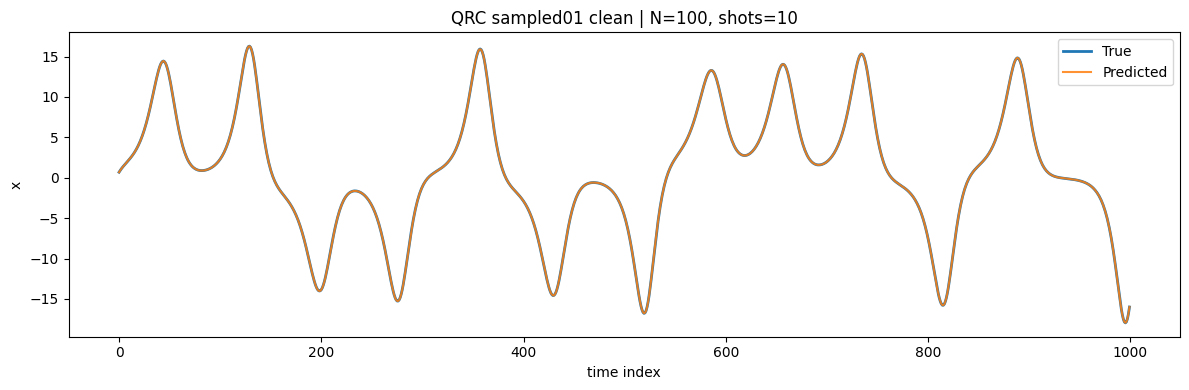

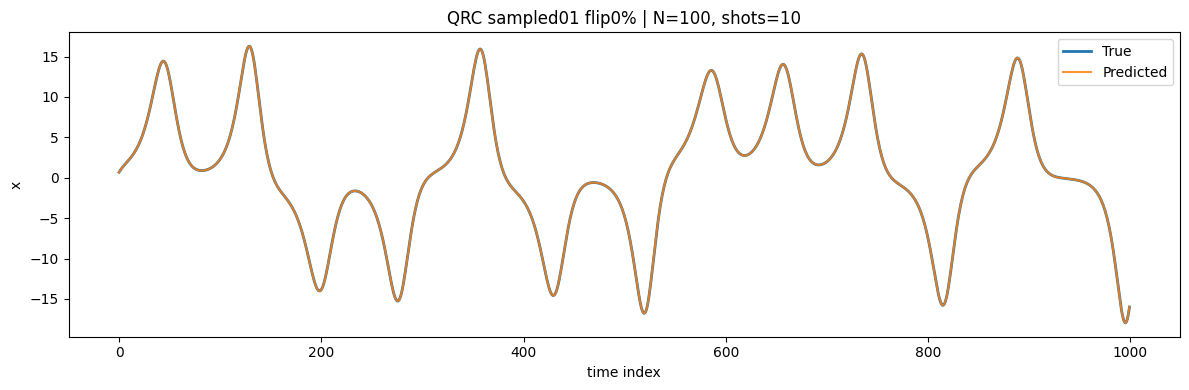

In [ ]:
# 例：x_series = lorenz_x_RK(6000) を先に用意しておく

N = 100
start_t = 1000
T = 1000
seed = 43

# (A) ノイズなし（shots平均だけ）
res_clean = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.0
)

# (B) フリップ10%
res_flip = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.00
)

print(f"[QRC sampled01 clean]  MSE={res_clean['mse']:.6f}  Corr={res_clean['corr']:.6f}")
print(f"[QRC sampled01 flip0] MSE={res_flip['mse']:.6f}  Corr={res_flip['corr']:.6f}")

plot_true_vs_pred(res_clean["Y"], res_clean["Yhat"], title=f"QRC sampled01 clean | N={N}, shots=10")
plot_true_vs_pred(res_flip["Y"],  res_flip["Yhat"],  title=f"QRC sampled01 flip0% | N={N}, shots=10")

[QRC sampled01 clean]  MSE=0.000054  Corr=1.000000
[QRC sampled01 flip05] MSE=0.000047  Corr=1.000000


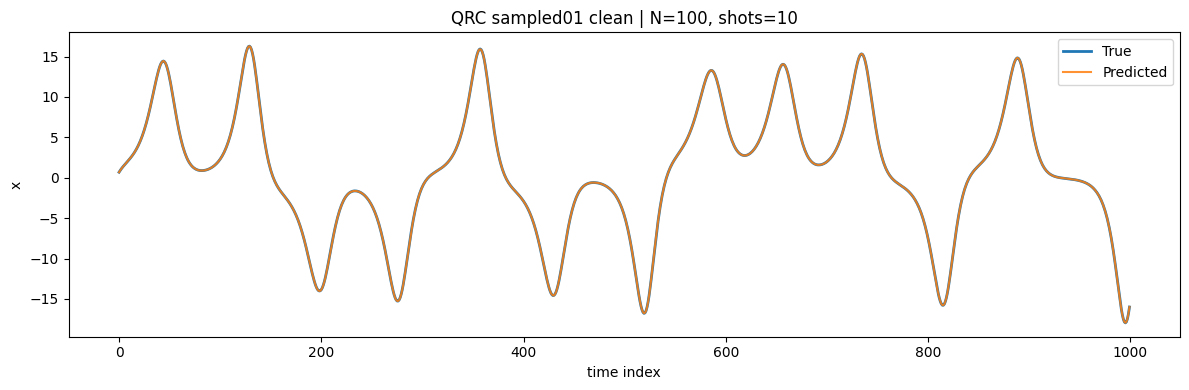

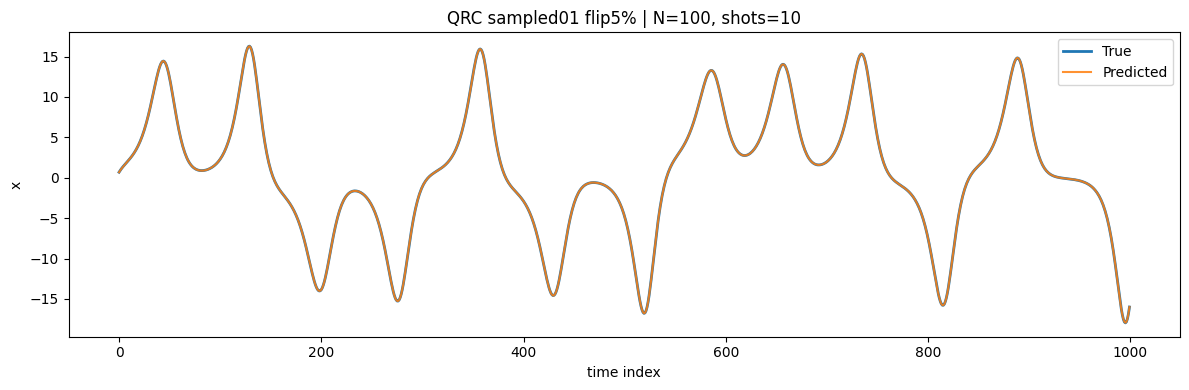

In [ ]:
# 例：x_series = lorenz_x_RK(6000) を先に用意しておく

N = 100
start_t = 1000
T = 1000
seed = 43

# (A) ノイズなし（shots平均だけ）
res_clean = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.0
)

# (B) フリップ10%
res_flip = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.05
)

print(f"[QRC sampled01 clean]  MSE={res_clean['mse']:.6f}  Corr={res_clean['corr']:.6f}")
print(f"[QRC sampled01 flip05] MSE={res_flip['mse']:.6f}  Corr={res_flip['corr']:.6f}")

plot_true_vs_pred(res_clean["Y"], res_clean["Yhat"], title=f"QRC sampled01 clean | N={N}, shots=10")
plot_true_vs_pred(res_flip["Y"],  res_flip["Yhat"],  title=f"QRC sampled01 flip5% | N={N}, shots=10")

[QRC sampled01 clean]  MSE=0.000054  Corr=1.000000
[QRC sampled01 flip10] MSE=0.000038  Corr=1.000000


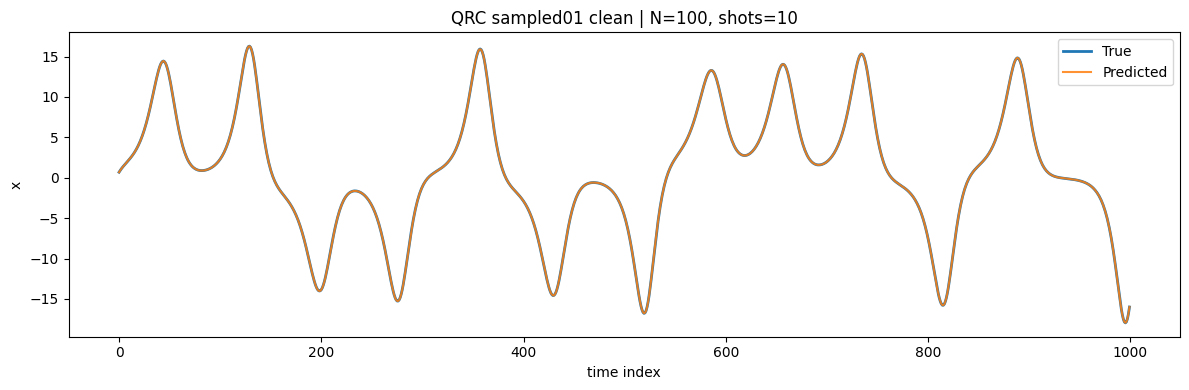

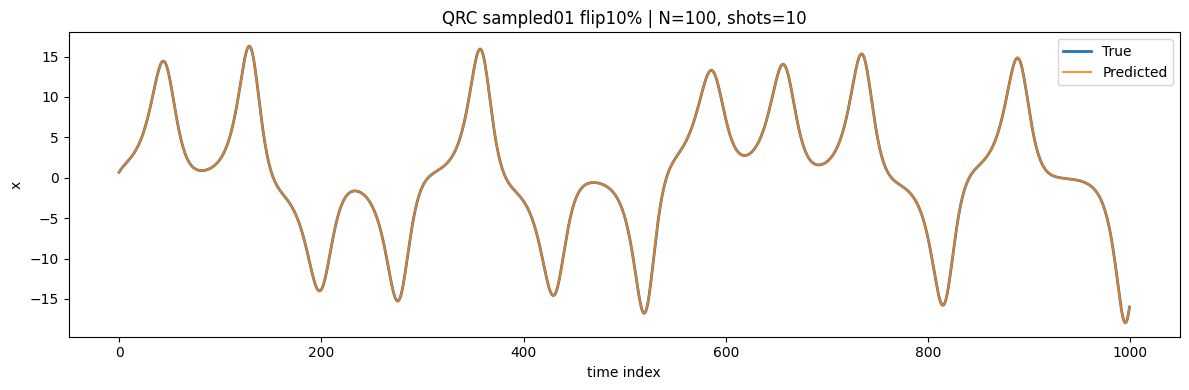

In [ ]:
# 例：x_series = lorenz_x_RK(6000) を先に用意しておく

N = 100
start_t = 1000
T = 1000
seed = 43

# (A) ノイズなし（shots平均だけ）
res_clean = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.0
)

# (B) フリップ10%
res_flip = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.10
)

print(f"[QRC sampled01 clean]  MSE={res_clean['mse']:.6f}  Corr={res_clean['corr']:.6f}")
print(f"[QRC sampled01 flip10] MSE={res_flip['mse']:.6f}  Corr={res_flip['corr']:.6f}")

plot_true_vs_pred(res_clean["Y"], res_clean["Yhat"], title=f"QRC sampled01 clean | N={N}, shots=10")
plot_true_vs_pred(res_flip["Y"],  res_flip["Yhat"],  title=f"QRC sampled01 flip10% | N={N}, shots=10")

[QRC sampled01 clean]  MSE=0.000054  Corr=1.000000
[QRC sampled01 flip10] MSE=0.000034  Corr=1.000000


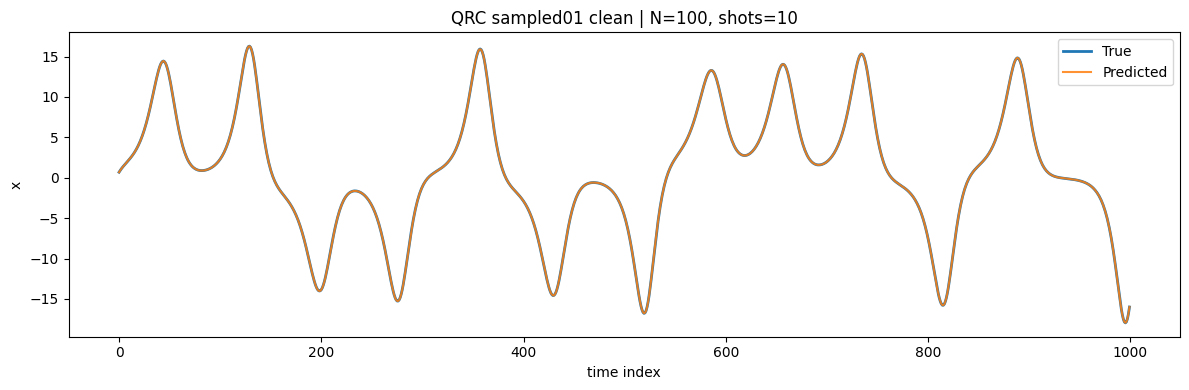

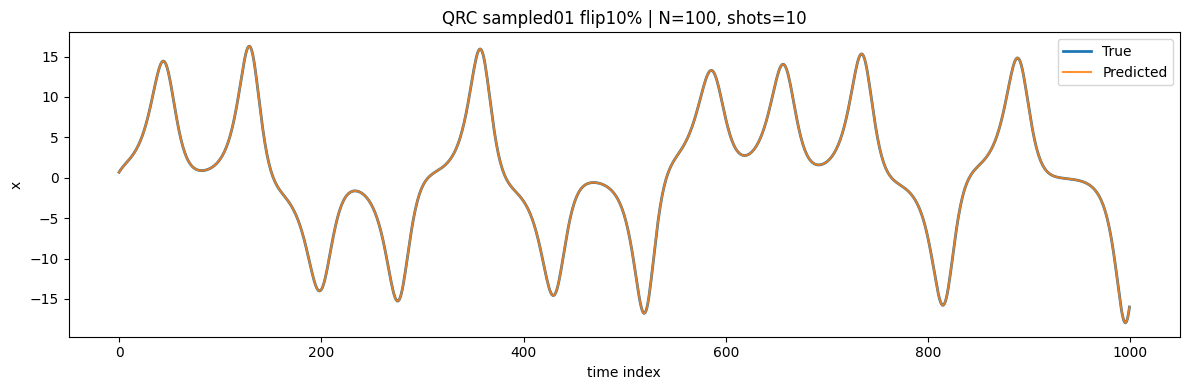

In [ ]:
# 例：x_series = lorenz_x_RK(6000) を先に用意しておく

N = 100
start_t = 1000
T = 1000
seed = 43

# (A) ノイズなし（shots平均だけ）
res_clean = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.0
)

# (B) フリップ12.5%
res_flip = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.125
)

print(f"[QRC sampled01 clean]  MSE={res_clean['mse']:.6f}  Corr={res_clean['corr']:.6f}")
print(f"[QRC sampled01 flip10] MSE={res_flip['mse']:.6f}  Corr={res_flip['corr']:.6f}")

plot_true_vs_pred(res_clean["Y"], res_clean["Yhat"], title=f"QRC sampled01 clean | N={N}, shots=10")
plot_true_vs_pred(res_flip["Y"],  res_flip["Yhat"],  title=f"QRC sampled01 flip12.5% | N={N}, shots=10")

[QRC sampled01 clean]  MSE=0.000054  Corr=1.000000
[QRC sampled01 flip15] MSE=0.000048  Corr=1.000000


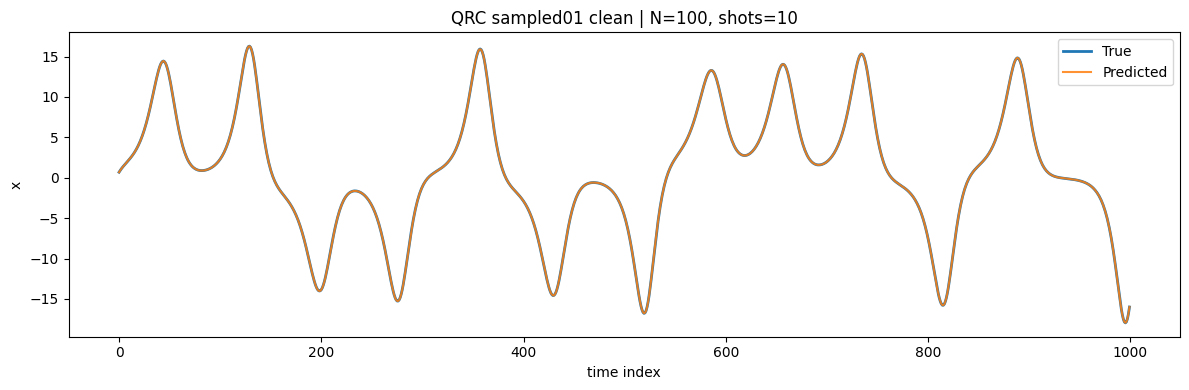

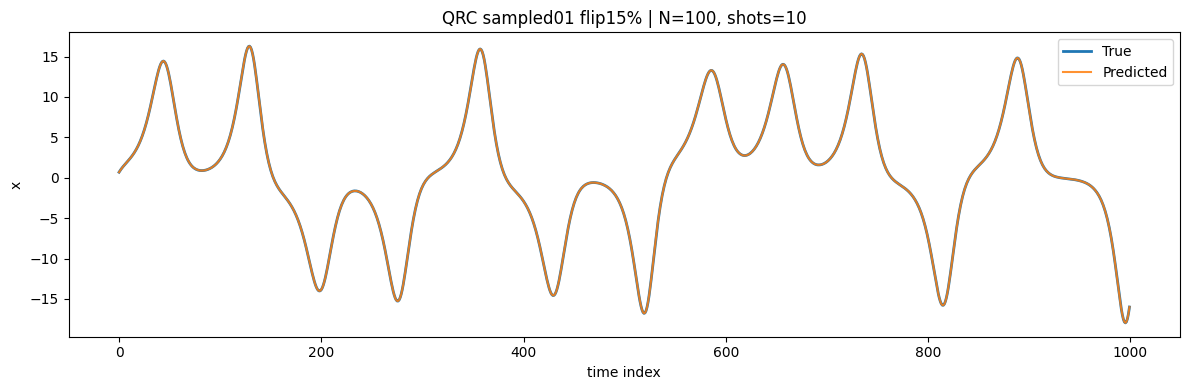

In [ ]:
# 例：x_series = lorenz_x_RK(6000) を先に用意しておく

N = 100
start_t = 1000
T = 1000
seed = 43

# (A) ノイズなし（shots平均だけ）
res_clean = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.0
)

# (B) フリップ15%
res_flip = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.15
)

print(f"[QRC sampled01 clean]  MSE={res_clean['mse']:.6f}  Corr={res_clean['corr']:.6f}")
print(f"[QRC sampled01 flip15] MSE={res_flip['mse']:.6f}  Corr={res_flip['corr']:.6f}")

plot_true_vs_pred(res_clean["Y"], res_clean["Yhat"], title=f"QRC sampled01 clean | N={N}, shots=10")
plot_true_vs_pred(res_flip["Y"],  res_flip["Yhat"],  title=f"QRC sampled01 flip15% | N={N}, shots=10")

[QRC sampled01 clean]  MSE=0.000054  Corr=1.000000
[QRC sampled01 flip20] MSE=0.000048  Corr=1.000000


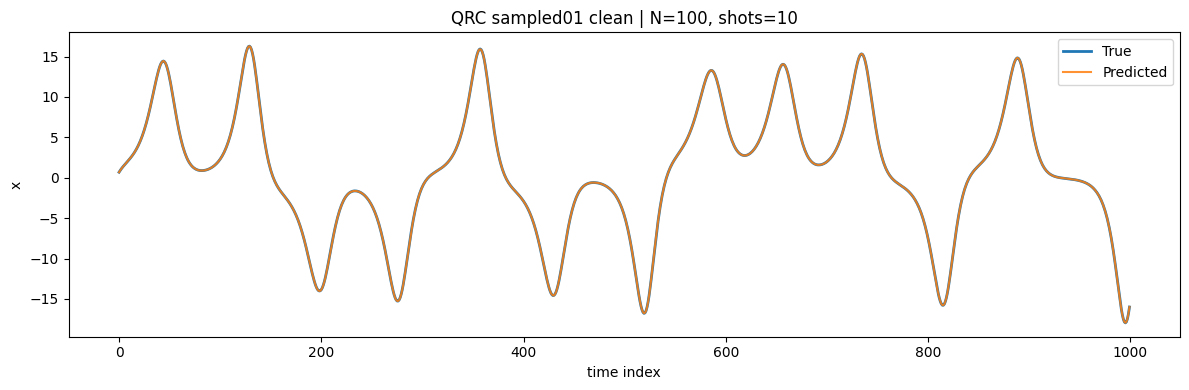

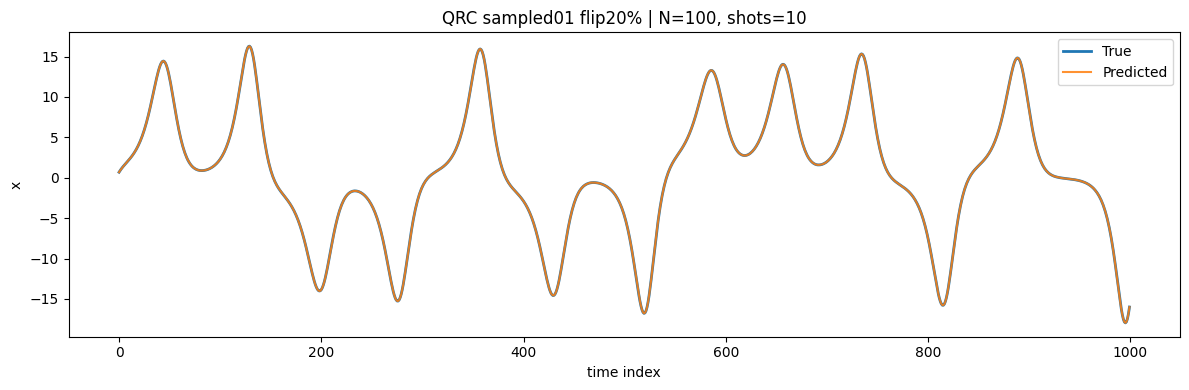

In [ ]:
# 例：x_series = lorenz_x_RK(6000) を先に用意しておく

N = 100
start_t = 1000
T = 1000
seed = 43

# (A) ノイズなし（shots平均だけ）
res_clean = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.0
)

# (B) フリップ20%
res_flip = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=10,
    flip_p=0.20
)

print(f"[QRC sampled01 clean]  MSE={res_clean['mse']:.6f}  Corr={res_clean['corr']:.6f}")
print(f"[QRC sampled01 flip20] MSE={res_flip['mse']:.6f}  Corr={res_flip['corr']:.6f}")

plot_true_vs_pred(res_clean["Y"], res_clean["Yhat"], title=f"QRC sampled01 clean | N={N}, shots=10")
plot_true_vs_pred(res_flip["Y"],  res_flip["Yhat"],  title=f"QRC sampled01 flip20% | N={N}, shots=10")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sweep_flip_noise_curve(
    x_series,
    *,
    N=100,
    start_t=1000,
    T=1000,
    seed=43,
    alpha=1.0,
    beta=0.7,
    squeeze_r=0.3,
    ridge=1e-2,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win_scale=1.0,
    carry_state=True,
    shots=10,
    flip_grid=None,
    n_seeds=1,            # seed をずらして平均したいなら >1
    seed_stride=1000,     # seedのずらし幅
    plot=True
):
    if flip_grid is None:
        flip_grid = np.linspace(0.0, 0.30, 16)  # 0%〜30% を16点

    flip_grid = np.asarray(flip_grid, float)

    mses_mean, mses_std = [], []
    corrs_mean, corrs_std = [], []

    for fp in flip_grid:
        mses, corrs = [], []
        for k in range(n_seeds):
            s = int(seed + k * seed_stride)
            res = qrc_teacher_forced_eval_sampled01(
                x_series,
                N=N, start_t=start_t, T=T, seed=s,
                alpha=alpha, beta=beta, squeeze_r=squeeze_r,
                ridge=ridge, norm_const=norm_const,
                sign_mode=sign_mode, input_mode=input_mode,
                Win_scale=Win_scale, carry_state=carry_state,
                shots=shots, flip_p=float(fp)
            )
            mses.append(res["mse"])
            corrs.append(res["corr"])

        mses = np.asarray(mses, float)
        corrs = np.asarray(corrs, float)
        mses_mean.append(mses.mean()); mses_std.append(mses.std(ddof=0))
        corrs_mean.append(corrs.mean()); corrs_std.append(corrs.std(ddof=0))

    mses_mean = np.asarray(mses_mean)
    mses_std  = np.asarray(mses_std)
    corrs_mean = np.asarray(corrs_mean)
    corrs_std  = np.asarray(corrs_std)

    if plot:
        # MSE vs flip_p
        plt.figure(figsize=(7,4))
        plt.errorbar(flip_grid, mses_mean, yerr=mses_std, fmt='o-', capsize=3)
        plt.xlabel("flip_p (measurement error probability)")
        plt.ylabel("MSE (teacher-forced 1-step)")
        plt.title(f"QRC sampled01: MSE vs flip_p  | N={N}, shots={shots}, T={T}, n_seeds={n_seeds}")
        plt.tight_layout()
        plt.show()

        # Corr vs flip_p
        plt.figure(figsize=(7,4))
        plt.errorbar(flip_grid, corrs_mean, yerr=corrs_std, fmt='o-', capsize=3)
        plt.xlabel("flip_p (measurement error probability)")
        plt.ylabel("Correlation (teacher-forced 1-step)")
        plt.title(f"QRC sampled01: Corr vs flip_p | N={N}, shots={shots}, T={T}, n_seeds={n_seeds}")
        plt.tight_layout()
        plt.show()

    return {
        "flip_grid": flip_grid,
        "mse_mean": mses_mean,
        "mse_std": mses_std,
        "corr_mean": corrs_mean,
        "corr_std": corrs_std,
    }

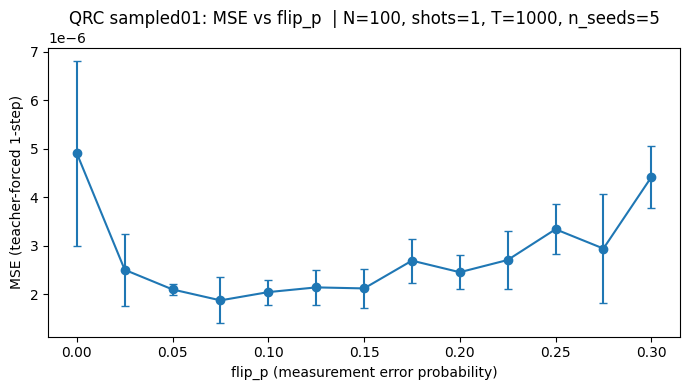

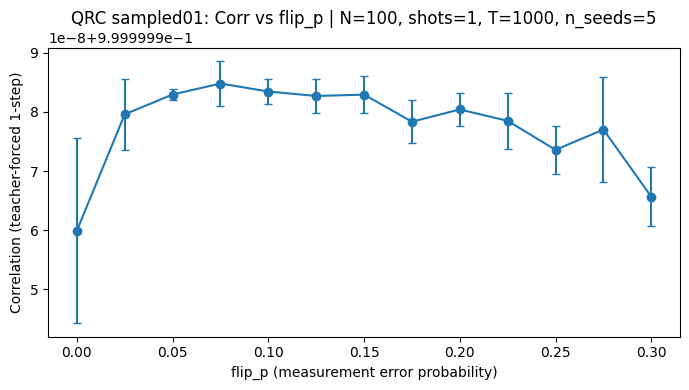

In [ ]:
# 例：既に x_series を作ってある前提
# x_series = lorenz_x_RK(6000)

out = sweep_flip_noise_curve(
    x_series,
    N=100, start_t=1000, T=1000,
    seed=43,
    shots=1,
    flip_grid=np.linspace(0, 0.30, 13),
    n_seeds=5,   # seed平均で滑らかに（時間が厳しければ 1 でOK）
)

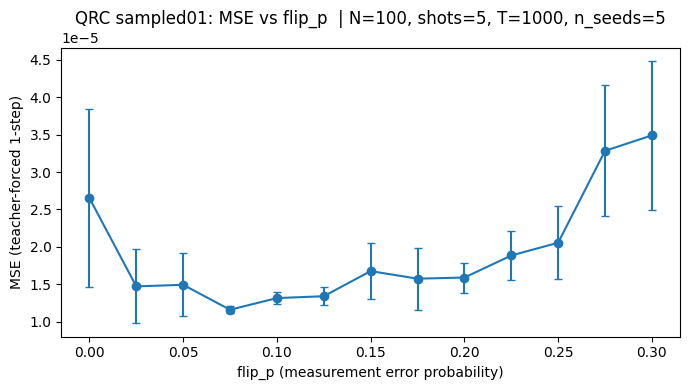

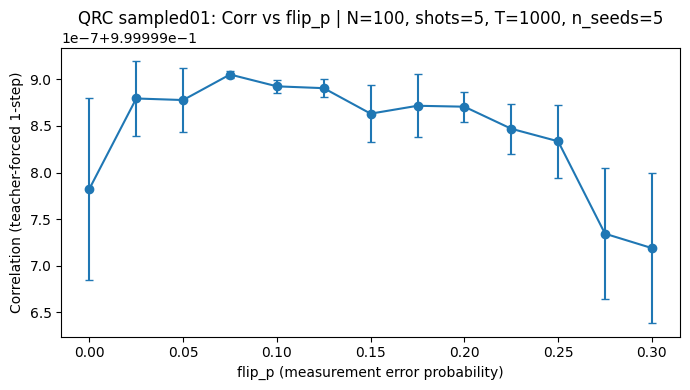

In [ ]:
# 例：既に x_series を作ってある前提
# x_series = lorenz_x_RK(6000)

out = sweep_flip_noise_curve(
    x_series,
    N=100, start_t=1000, T=1000,
    seed=43,
    shots=5,
    flip_grid=np.linspace(0, 0.30, 13),
    n_seeds=5,   # seed平均で滑らかに（時間が厳しければ 1 でOK）
)

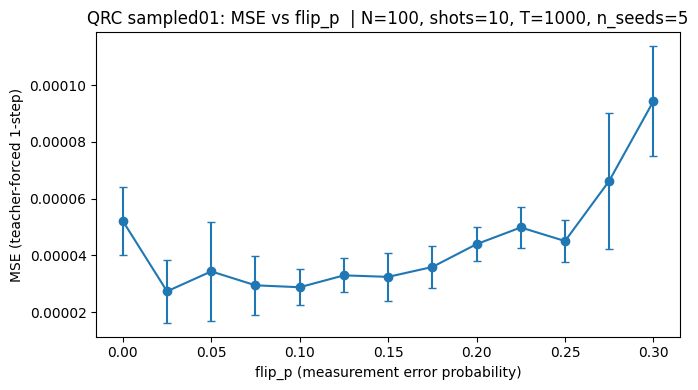

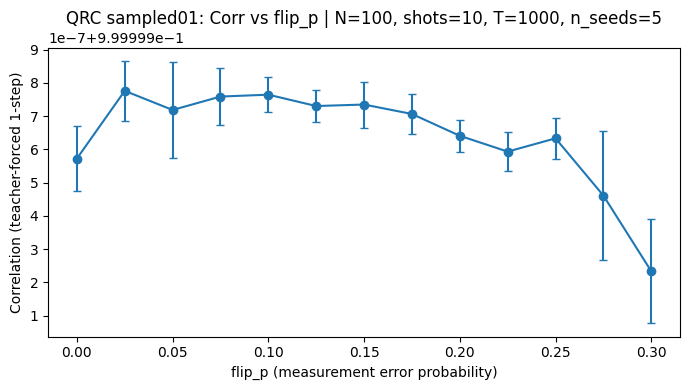

In [ ]:
# 例：既に x_series を作ってある前提
# x_series = lorenz_x_RK(6000)

out = sweep_flip_noise_curve(
    x_series,
    N=100, start_t=1000, T=1000,
    seed=43,
    shots=10,
    flip_grid=np.linspace(0, 0.30, 13),
    n_seeds=5,   # seed平均で滑らかに（時間が厳しければ 1 でOK）
)

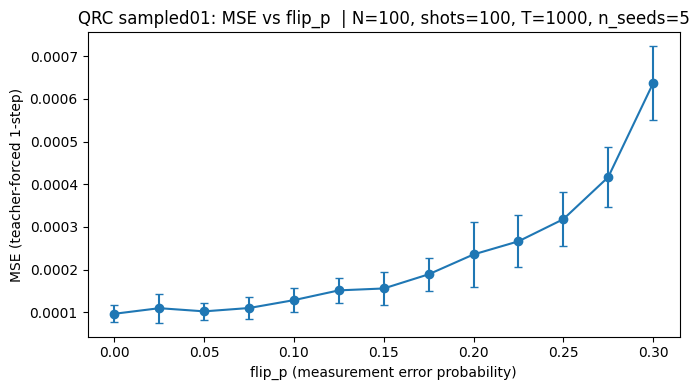

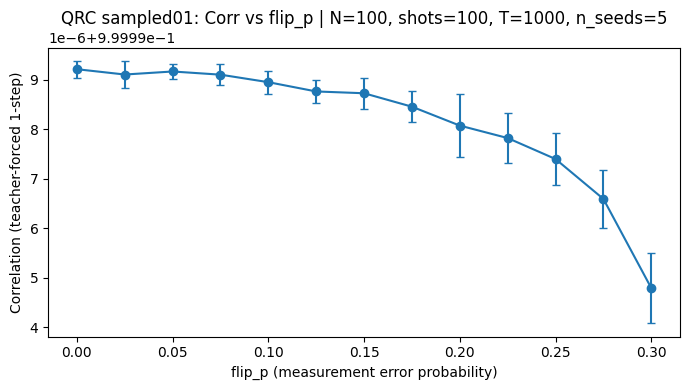

In [ ]:
out = sweep_flip_noise_curve(
    x_series,
    N=100, start_t=1000, T=1000,
    seed=43,
    shots=100,
    flip_grid=np.linspace(0, 0.30, 13),
    n_seeds=5,   # seed平均で滑らかに（時間が厳しければ 1 でOK）
)

In [ ]:
def sweep_shots_and_flip_heatmap(
    x_series,
    *,
    N=100,
    start_t=1000,
    T=1000,
    seed=43,
    alpha=1.0,
    beta=0.7,
    squeeze_r=0.3,
    ridge=1e-2,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win_scale=1.0,
    carry_state=True,
    shots_list=(1, 2, 3, 5, 10, 20, 50),
    flip_grid=None,
    plot=True
):
    if flip_grid is None:
        flip_grid = np.linspace(0.0, 0.30, 16)
    flip_grid = np.asarray(flip_grid, float)
    shots_list = list(map(int, shots_list))

    MSE = np.zeros((len(shots_list), len(flip_grid)), dtype=float)
    CORR = np.zeros_like(MSE)

    for i, shots in enumerate(shots_list):
        for j, fp in enumerate(flip_grid):
            res = qrc_teacher_forced_eval_sampled01(
                x_series,
                N=N, start_t=start_t, T=T, seed=seed,
                alpha=alpha, beta=beta, squeeze_r=squeeze_r,
                ridge=ridge, norm_const=norm_const,
                sign_mode=sign_mode, input_mode=input_mode,
                Win_scale=Win_scale, carry_state=carry_state,
                shots=shots, flip_p=float(fp)
            )
            MSE[i, j] = res["mse"]
            CORR[i, j] = res["corr"]

    if plot:
        plt.figure(figsize=(8,5))
        plt.imshow(MSE, aspect='auto', origin='lower',
                   extent=[flip_grid[0], flip_grid[-1], shots_list[0], shots_list[-1]])
        plt.colorbar(label="MSE")
        plt.xlabel("flip_p")
        plt.ylabel("shots")
        plt.title(f"QRC sampled01: MSE heatmap | N={N}, T={T}, seed={seed}")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8,5))
        plt.imshow(CORR, aspect='auto', origin='lower',
                   extent=[flip_grid[0], flip_grid[-1], shots_list[0], shots_list[-1]],
                   vmin=0.0, vmax=1.0)
        plt.colorbar(label="Corr")
        plt.xlabel("flip_p")
        plt.ylabel("shots")
        plt.title(f"QRC sampled01: Corr heatmap | N={N}, T={T}, seed={seed}")
        plt.tight_layout()
        plt.show()

    return {"shots_list": shots_list, "flip_grid": flip_grid, "MSE": MSE, "CORR": CORR}

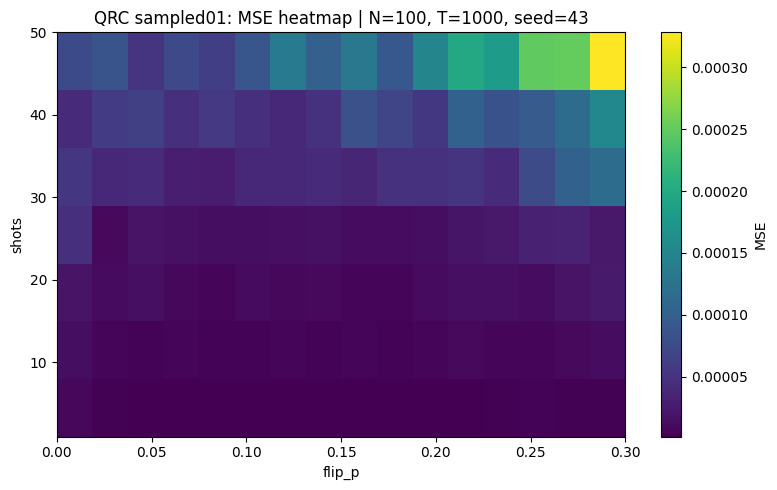

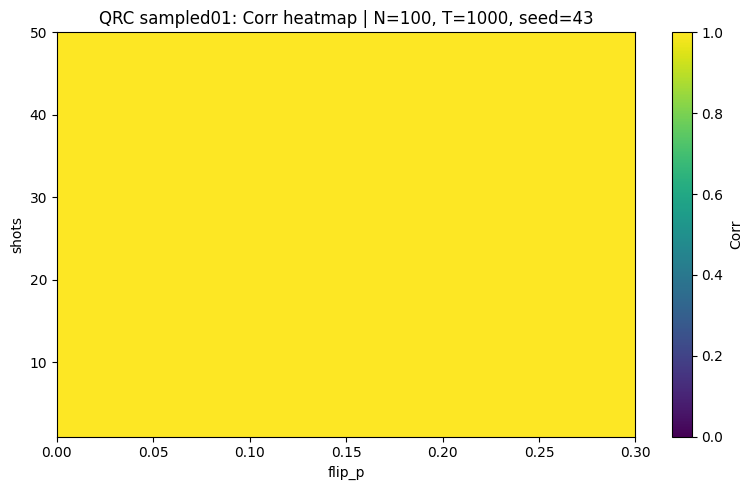

In [ ]:
heat = sweep_shots_and_flip_heatmap(
    x_series,
    N=100, start_t=1000, T=1000,
    seed=43,
    shots_list=(1, 2, 3, 5, 10, 20, 50),
    flip_grid=np.linspace(0, 0.30, 16),
)

shots を増やす

→ 大数の法則で分散が潰れる

→Bernoulli測定が “ただの平均値 p” に近づく

→QRC が「平均値のみを使うリザバー」に退化する

→それまで効いていた “暗黙の正則化＋非線形ランダム特徴” が消える

→MSE が上がる

**つまり、最適はショット数1の時！**

[QRC sampled01 clean]  MSE=0.000008  Corr=1.000000
[QRC sampled01 flip7.5] MSE=0.000002  Corr=1.000000


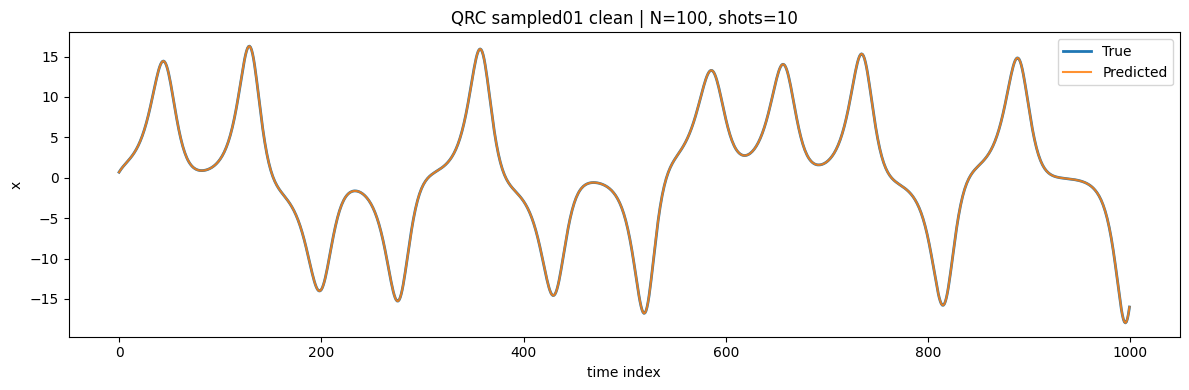

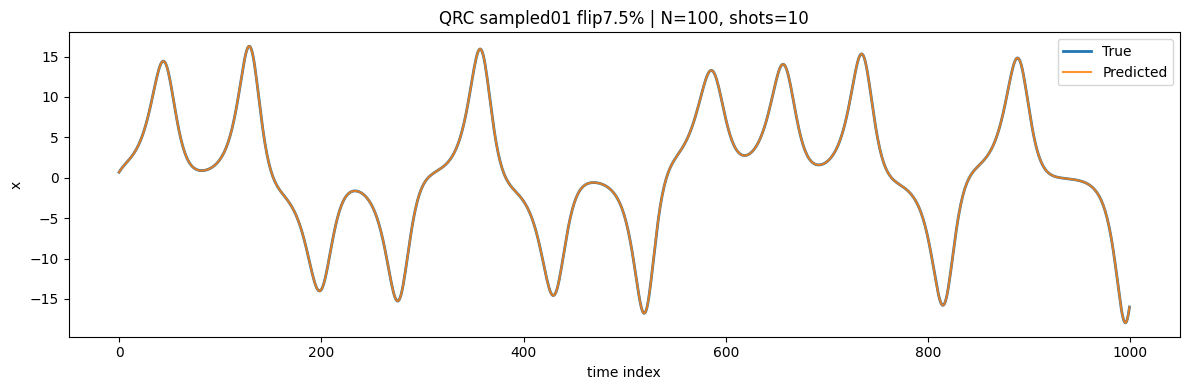

In [ ]:
N = 100
start_t = 1000
T = 1000
seed = 43

# (A) ノイズなし（shots平均だけ）
res_clean = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=1,
    flip_p=0.0
)

# (B) フリップ20%
res_flip = qrc_teacher_forced_eval_sampled01(
    x_series,
    N=N, start_t=start_t, T=T, seed=seed,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2,
    shots=1,
    flip_p=0.075
)

print(f"[QRC sampled01 clean]  MSE={res_clean['mse']:.6f}  Corr={res_clean['corr']:.6f}")
print(f"[QRC sampled01 flip7.5] MSE={res_flip['mse']:.6f}  Corr={res_flip['corr']:.6f}")

plot_true_vs_pred(res_clean["Y"], res_clean["Yhat"], title=f"QRC sampled01 clean | N={N}, shots=10")
plot_true_vs_pred(res_flip["Y"],  res_flip["Yhat"],  title=f"QRC sampled01 flip7.5% | N={N}, shots=10")

QRC MSE mean/std/min/max: 2.4251561254565292e-06 6.010252997110543e-07 1.399637788545153e-06 3.7763440477213307e-06
QRC Corr mean/std/min/max: 0.9999999803008508 4.893186700707394e-09 0.999999969241006 0.9999999886501785


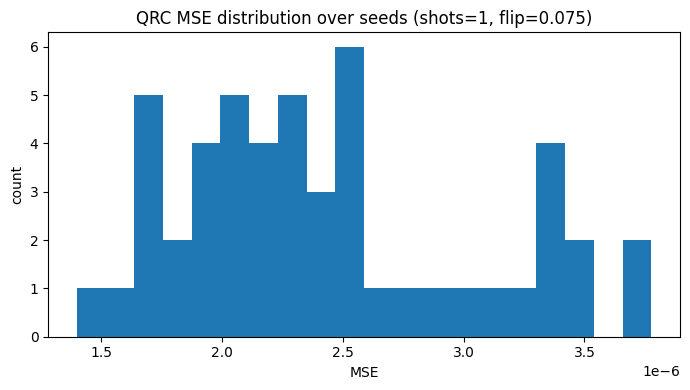

In [ ]:
def eval_many_seeds_qrc(
    x_series, *,
    seeds, N=100, start_t=1000, T=1000,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    ridge=1e-2, norm_const=1.0,
    sign_mode="plus", input_mode="scale",
    shots=1, flip_p=0.075,
):
    mses, corrs = [], []
    for seed in seeds:
        res = qrc_teacher_forced_eval_sampled01(
            x_series,
            N=N, start_t=start_t, T=T, seed=int(seed),
            alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            ridge=ridge, norm_const=norm_const,
            sign_mode=sign_mode, input_mode=input_mode,
            shots=shots, flip_p=flip_p
        )
        mses.append(res["mse"]); corrs.append(res["corr"])
    return np.array(mses), np.array(corrs)

seeds = np.arange(0, 50) + 100  # 50本
mses, corrs = eval_many_seeds_qrc(
    x_series, seeds=seeds,
    N=100, start_t=1000, T=1000,
    shots=1, flip_p=0.075
)

print("QRC MSE mean/std/min/max:", mses.mean(), mses.std(), mses.min(), mses.max())
print("QRC Corr mean/std/min/max:", corrs.mean(), corrs.std(), corrs.min(), corrs.max())
plt.figure(figsize=(7,4))
plt.hist(mses, bins=20)
plt.title("QRC MSE distribution over seeds (shots=1, flip=0.075)")
plt.xlabel("MSE"); plt.ylabel("count"); plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# -------------------------
# データセット: 入力 U10=[x(t-9)..x(t)], 教師 Y=x(t+1)
# -------------------------
def make_window10_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 9:
        raise ValueError("start_t must be >= 9")
    if start_t + T + 1 > len(x):
        raise ValueError("range out of x_series (need t+1)")
    U10 = np.vstack([x[t-9:t+1] for t in range(start_t, start_t + T)])  # (T,10)
    Y = x[start_t + 1 : start_t + T + 1]                                # (T,)
    return U10, Y

# -------------------------
# 共通: ridge readout（bias付き、biasは正則化しない）
# -------------------------
def fit_readout_ridge(S: np.ndarray, Y: np.ndarray, ridge: float = 1e-2) -> Tuple[np.ndarray, float]:
    S = np.asarray(S, float)
    Y = np.asarray(Y, float).reshape(-1)
    T, M = S.shape
    if Y.size != T:
        raise ValueError("S and Y length mismatch")

    X = np.hstack([S, np.ones((T, 1))])  # (T, M+1)
    Reg = np.diag(np.append(np.full(M, ridge), 0.0))  # biasは正則化しない
    theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)
    w = theta[:M]
    b = float(theta[M])
    return w, b

def predict_readout(S: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    return np.asarray(S, float) @ np.asarray(w, float) + float(b)

def mse_corr(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    y_true = np.asarray(y_true, float).reshape(-1)
    y_pred = np.asarray(y_pred, float).reshape(-1)
    mse = float(np.mean((y_true - y_pred) ** 2))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    return mse, corr

def plot_true_vs_pred(y_true, y_pred, title=""):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label="True", lw=2)
    plt.plot(y_pred, label="Predicted", lw=1.5, alpha=0.85)
    plt.title(title)
    plt.xlabel("time index")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================================================
# (A) QRC: 0/1サンプリング + flip + shots平均 で状態列を作る
# =========================================================
def simulate_qrc_states_sampled01(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U10: np.ndarray,            # (T,10)
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",    # "pm" or "plus"
    input_mode: str = "scale",  # "scale" or "replace"
    Win: Optional[np.ndarray] = None,   # (10,M)
    Win_scale: float = 1.0,
    carry_state: bool = True,
    shots: int = 10,
    flip_p: float = 0.0,        # 測定反転確率
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      S:  (T,M)  shots平均した0/1検出（=検出率推定）
      xT: (M,)   最終状態（無励起確率として保持）
    """
    U10 = np.asarray(U10, float)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError("U10 must be (T,10)")
    T = U10.shape[0]
    M = 12 * N

    rng = np.random.default_rng(seed)

    # 入力マスク (10,M)
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(10, M)) * (float(Win_scale) / np.sqrt(10.0))
    else:
        Win = np.asarray(Win, float)
        if Win.shape != (10, M):
            raise ValueError(f"Win must be (10,{M})")

    # 状態（無励起確率）
    x_state = np.zeros(M, dtype=float)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    shots = max(1, int(shots))
    flip_p = float(flip_p)
    if not (0.0 <= flip_p <= 0.5):
        raise ValueError("flip_p must be in [0,0.5]")

    for t in range(T):
        # 10次元窓 → M次元入力
        u_vec = U10[t] @ Win  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ① 確率注入
        p = np.clip(x_state, 0.0, 1.0)      # 無励起確率
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)          # Trueなら励起

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # ②〜⑤ ネットワーク
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / sqrt2

        # ⑧ 非線形（安全版）：logで計算して overflow を回避
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)

        # log p0_like = log(coef) - |fin|^2 + tanh(r)*fin^2
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        # exp の安全域にクリップ（複素expを扱うので実部だけクリップ）
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        # ---- 0/1測定（shots回） + flip ----
        # Bernoulli(out_prob) を shots 回サンプルし平均
        # shape: (shots, M)
        draws = (rng.random((shots, M)) < out_prob[None, :]).astype(np.int8)

        if flip_p > 0.0:
            flips = (rng.random((shots, M)) < flip_p).astype(np.int8)
            draws = draws ^ flips  # XORで反転

        out_mean = draws.mean(axis=0).astype(float)  # (M,)

        S[t] = out_mean

        if carry_state:
            # 無励起確率として更新したいなら 1-out_mean が整合
            x_state = np.clip(1.0 - out_mean, 0.0, 1.0)

    return S, x_state

# =========================================================
# (B) 決定論的 ESN (tanh)：ユーザー提示コードと同等
# =========================================================
def simulate_esn_states_tanh(
    M: int,
    U10: np.ndarray,  # (T,10)
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    U10 = np.asarray(U10, float)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError("U10 must be (T,10)")
    T = U10.shape[0]
    rng = np.random.default_rng(seed)

    Win = rng.uniform(-1.0, 1.0, size=(10, M)) * float(input_scale)

    Wres = rng.normal(0.0, 1.0, size=(M, M)) / np.sqrt(M)
    eigvals = np.linalg.eigvals(Wres)
    sr = np.max(np.abs(eigvals)) + 1e-12
    Wres = Wres * (float(spectral_radius) / sr)

    b = rng.uniform(-1.0, 1.0, size=M) * float(bias_scale)

    x = np.zeros(M, dtype=float)
    S = np.empty((T, M), dtype=float)

    leak = float(leak_rate)
    for t in range(T):
        pre = x @ Wres + U10[t] @ Win + b
        x_new = np.tanh(pre)
        x = (1.0 - leak) * x + leak * x_new
        S[t] = x

    params = {"Wres": Wres, "Win": Win, "b": b}
    return S, params

# =========================================================
# 比較：QRC sampled01+flip vs ESN tanh
# =========================================================
def compare_qrc_sampled01_vs_esn(
    x_series: np.ndarray,
    *,
    N: int = 100,
    start_t: int = 1000,
    T: int = 1000,
    seed: int = 43,
    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    shots: int = 10,
    flip_p: float = 0.0,
    ridge: float = 1e-2,
    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    U10, Y = make_window10_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    # --- QRC
    S_qrc, _ = simulate_qrc_states_sampled01(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U10=U10,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    wq, bq = fit_readout_ridge(S_qrc, Y, ridge=ridge)
    Yhat_qrc = predict_readout(S_qrc, wq, bq)
    mse_qrc, corr_qrc = mse_corr(Y, Yhat_qrc)

    # --- ESN
    S_esn, _ = simulate_esn_states_tanh(
        M=M, U10=U10,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn, Y, ridge=ridge)
    Yhat_esn = predict_readout(S_esn, we, be)
    mse_esn, corr_esn = mse_corr(Y, Yhat_esn)

    print(f"[QRC sampled01] M={M} shots={shots} flip={flip_p:.3f}  MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN tanh]     M={M}                        MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")

    plot_true_vs_pred(Y, Yhat_qrc, title=f"QRC sampled01 Teacher-forced 1-step | N={N}, M={M}, shots={shots}, flip={flip_p:.3f}")
    plot_true_vs_pred(Y, Yhat_esn, title=f"ESN (tanh) Teacher-forced 1-step | M={M}")

    return {
        "Y": Y,
        "Yhat_qrc": Yhat_qrc,
        "Yhat_esn": Yhat_esn,
        "metrics": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        }
    }

[QRC sampled01] M=1200 shots=1 flip=0.075  MSE=0.000002  Corr=1.000000
[ESN tanh]     M=1200                        MSE=0.000009  Corr=1.000000


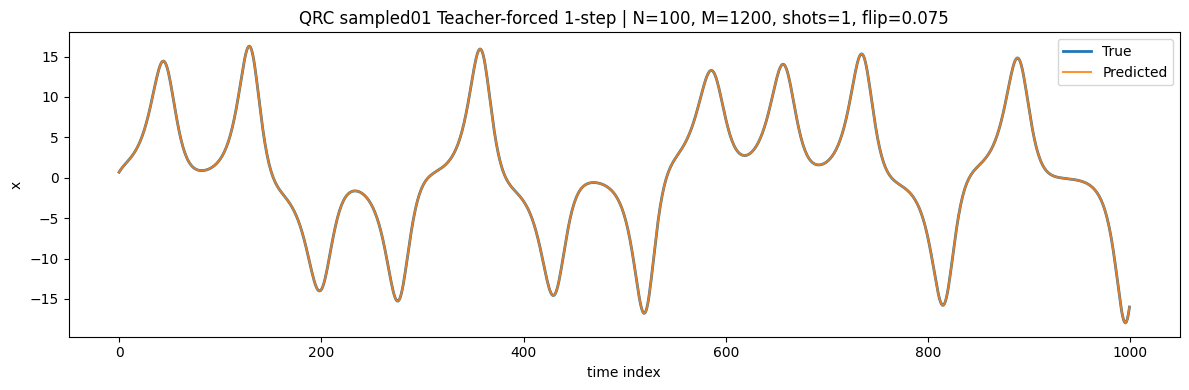

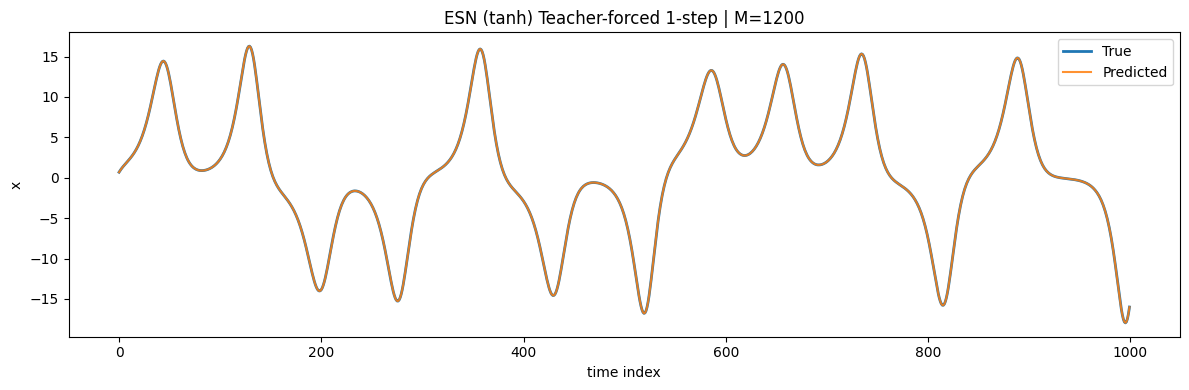

In [ ]:
# x_series は既に作ってある前提（例：x_series = lorenz_x_RK(6000)）

res = compare_qrc_sampled01_vs_esn(
    x_series,
    N=100, start_t=1000, T=1000, seed=43,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    shots=1, flip_p=0.075,
    ridge=1e-2,
    spectral_radius=0.9, input_scale_esn=0.5, leak_rate=1.0, bias_scale=0.1,
)

In [ ]:
import numpy as np
from typing import Tuple, Optional, Dict

# ------------------------------------------------------------
# ESN: 決定論状態 x(t) を作る（通常の ESN）
# ------------------------------------------------------------
def simulate_esn_states_tanh(
    M: int,
    U10: np.ndarray,  # (T,10)
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    U10 = np.asarray(U10, float)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError("U10 must be (T,10)")
    T = U10.shape[0]
    rng = np.random.default_rng(seed)

    Win = rng.uniform(-1.0, 1.0, size=(10, M)) * float(input_scale)

    Wres = rng.normal(0.0, 1.0, size=(M, M)) / np.sqrt(M)
    eigvals = np.linalg.eigvals(Wres)
    sr = np.max(np.abs(eigvals)) + 1e-12
    Wres = Wres * (float(spectral_radius) / sr)

    b = rng.uniform(-1.0, 1.0, size=M) * float(bias_scale)

    x = np.zeros(M, dtype=float)
    S = np.empty((T, M), dtype=float)

    leak = float(leak_rate)
    for t in range(T):
        pre = x @ Wres + U10[t] @ Win + b
        x_new = np.tanh(pre)
        x = (1.0 - leak) * x + leak * x_new
        S[t] = x

    params = {"Wres": Wres, "Win": Win, "b": b}
    return S, params

# ------------------------------------------------------------
# ESN: 「QRCと同型」の測定ノイズをかける
# - x_det: (T,M) in [-1,1]
# - p: (T,M) in [0,1] へ写像
# - shots回 Bernoulli(p) をサンプルして平均
# - flip_p で反転
# ------------------------------------------------------------
def esn_measurement_sampled01(
    x_det: np.ndarray,
    *,
    seed: int = 43,
    shots: int = 1,
    flip_p: float = 0.0,
    prob_map: str = "affine",   # "affine" or "sigmoid"
    sigmoid_k: float = 1.0,     # sigmoidの鋭さ
) -> np.ndarray:
    """
    Returns:
      z: (T,M) in [0,1]  (0/1測定の shots 平均)
    """
    x_det = np.asarray(x_det, float)
    if x_det.ndim != 2:
        raise ValueError("x_det must be (T,M)")
    T, M = x_det.shape

    rng = np.random.default_rng(seed)
    shots = max(1, int(shots))
    flip_p = float(flip_p)
    if not (0.0 <= flip_p <= 0.5):
        raise ValueError("flip_p must be in [0,0.5]")

    # 確率へ写像
    if prob_map == "affine":
        # tanh状態 x∈[-1,1] を p∈[0,1] へ：最も素直
        p = 0.5 * (x_det + 1.0)
    elif prob_map == "sigmoid":
        # もう少し一般的に：p = sigmoid(k*x)
        p = 1.0 / (1.0 + np.exp(-float(sigmoid_k) * x_det))
    else:
        raise ValueError('prob_map must be "affine" or "sigmoid"')

    p = np.clip(p, 0.0, 1.0)

    # shots回サンプル（ベクトル化）
    # draws: (shots, T, M)
    draws = (rng.random((shots, T, M)) < p[None, :, :]).astype(np.int8)

    # flip
    if flip_p > 0.0:
        flips = (rng.random((shots, T, M)) < flip_p).astype(np.int8)
        draws = draws ^ flips

    z = draws.mean(axis=0).astype(float)  # (T,M)
    return z

# ------------------------------------------------------------
# ESN + 測定ノイズ込みの状態列を作る（便利ラッパー）
# ------------------------------------------------------------
def simulate_esn_states_sampled01(
    M: int,
    U10: np.ndarray,
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
    shots: int = 1,
    flip_p: float = 0.0,
    prob_map: str = "affine",
    sigmoid_k: float = 1.0,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    x_det, params = simulate_esn_states_tanh(
        M=M, U10=U10,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    z = esn_measurement_sampled01(
        x_det,
        seed=seed + 99991,  # 状態生成と測定乱数を分離したいのでseedをずらす
        shots=shots,
        flip_p=flip_p,
        prob_map=prob_map,
        sigmoid_k=sigmoid_k,
    )
    params = dict(params)
    params.update({"prob_map": prob_map, "sigmoid_k": sigmoid_k, "shots": shots, "flip_p": flip_p})
    return z, params

def compare_qrc_vs_esn_with_same_measurement_noise(
    x_series,
    *,
    N=100,
    start_t=1000,
    T=1000,
    seed=43,
    ridge=1e-2,
    # QRC measurement
    shots=1,
    flip_p=0.075,
    # ESN core
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
    prob_map="affine",     # ESNの状態→確率の写像
    sigmoid_k=1.0,
    # QRC params（あなたの関数がある前提）
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win_scale_qrc=1.0,
    carry_state=True,
):
    # 1) データセット
    U10, Y = make_window10_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    # 2) QRC states (あなたの実装を呼ぶ)
    S_qrc, _ = simulate_qrc_states_sampled01(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U10=U10,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    wq, bq = fit_readout_ridge(S_qrc, Y, ridge=ridge)
    Yhat_qrc = predict_readout(S_qrc, wq, bq)
    mse_qrc, corr_qrc = mse_corr(Y, Yhat_qrc)

    # 3) ESN states + same measurement noise
    S_esn_noisy, _ = simulate_esn_states_sampled01(
        M=M, U10=U10,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
        shots=shots,
        flip_p=flip_p,
        prob_map=prob_map,
        sigmoid_k=sigmoid_k,
    )
    we, be = fit_readout_ridge(S_esn_noisy, Y, ridge=ridge)
    Yhat_esn = predict_readout(S_esn_noisy, we, be)
    mse_esn, corr_esn = mse_corr(Y, Yhat_esn)

    print(f"[QRC sampled01] M={M} shots={shots} flip={flip_p:.3f}  MSE={mse_qrc:.6e}  Corr={corr_qrc:.9f}")
    print(f"[ESN + same meas] M={M} shots={shots} flip={flip_p:.3f}  MSE={mse_esn:.6e}  Corr={corr_esn:.9f}  (prob_map={prob_map})")

    plot_true_vs_pred(Y, Yhat_qrc, title=f"QRC | shots={shots}, flip={flip_p:.3f}")
    plot_true_vs_pred(Y, Yhat_esn, title=f"ESN + same measurement noise | shots={shots}, flip={flip_p:.3f}, map={prob_map}")

    return {
        "metrics": {"qrc": (mse_qrc, corr_qrc), "esn_noisy": (mse_esn, corr_esn)},
        "Y": Y, "Yhat_qrc": Yhat_qrc, "Yhat_esn": Yhat_esn
    }

[QRC sampled01] M=1200 shots=1 flip=0.075  MSE=2.388142e-06  Corr=0.999999981
[ESN + same meas] M=1200 shots=1 flip=0.075  MSE=1.731667e-06  Corr=0.999999986  (prob_map=affine)


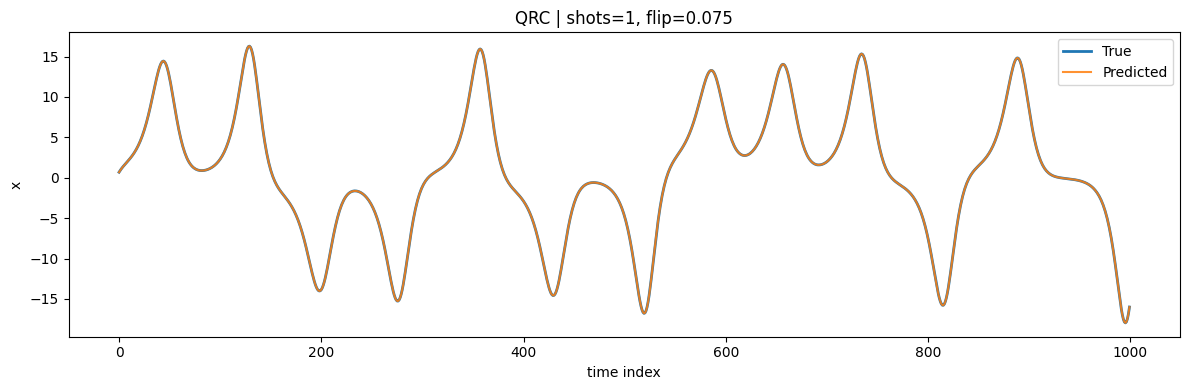

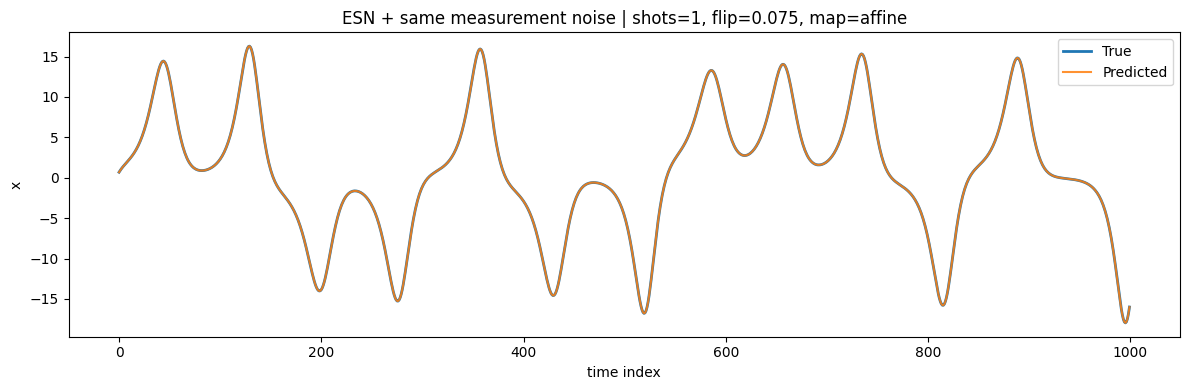

In [ ]:
res = compare_qrc_vs_esn_with_same_measurement_noise(
    x_series,
    N=100, start_t=1000, T=1000, seed=43,
    shots=1, flip_p=0.075,
    prob_map="affine"   # まずはこれが一番自然
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def summarize(arr):
    arr = np.asarray(arr, float)
    return {
        "mean": float(np.mean(arr)),
        "std":  float(np.std(arr, ddof=1)),
        "min":  float(np.min(arr)),
        "max":  float(np.max(arr)),
    }

def plot_overlaid_hist(q_mse, e_mse, title="MSE distribution over seeds"):
    plt.figure(figsize=(9,4))
    plt.hist(q_mse, bins=25, alpha=0.6, label="QRC", density=True)
    plt.hist(e_mse, bins=25, alpha=0.6, label="ESN (+same meas noise)", density=True)
    plt.title(title)
    plt.xlabel("MSE")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_scatter(q_mse, e_mse, title="Per-seed MSE: QRC vs ESN"):
    plt.figure(figsize=(5,5))
    plt.scatter(e_mse, q_mse, alpha=0.8)
    mn = min(np.min(e_mse), np.min(q_mse))
    mx = max(np.max(e_mse), np.max(q_mse))
    plt.plot([mn, mx], [mn, mx], "--")
    plt.xlabel("ESN MSE")
    plt.ylabel("QRC MSE")
    plt.title(title + "\n(below diagonal = QRC better)")
    plt.tight_layout()
    plt.show()

def paired_tests(q_mse, e_mse):
    q_mse = np.asarray(q_mse, float)
    e_mse = np.asarray(e_mse, float)
    diff = e_mse - q_mse  # +ならESNが悪い（QRCが良い）

    t_stat, p_two = stats.ttest_rel(e_mse, q_mse)
    dz = float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-12))  # Cohen's dz

    return {
        "mean_diff(ESN-QRC)": float(np.mean(diff)),
        "std_diff": float(np.std(diff, ddof=1)),
        "t_stat": float(t_stat),
        "p_val_two_sided": float(p_two),
        "cohens_dz": dz,
        "fraction_QRC_better": float(np.mean(q_mse < e_mse)),
    }

def seed_sweep_qrc_vs_esn(
    x_series,
    seeds,
    *,
    N=100,
    start_t=1000,
    T=1000,
    ridge=1e-2,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    norm_const=1.0, sign_mode="plus", input_mode="scale",
    Win_scale_qrc=1.0, carry_state=True,
    shots=1, flip_p=0.075,
    # ESN core
    spectral_radius=0.9, input_scale_esn=0.5, leak_rate=1.0, bias_scale=0.1,
    prob_map="affine", sigmoid_k=1.0,
):
    U10, Y = make_window10_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    q_mse, q_corr = [], []
    e_mse, e_corr = [], []

    for sd in seeds:
        sd = int(sd)

        # --- QRC ---
        S_qrc, _ = simulate_qrc_states_sampled01(
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            U10=U10,
            seed=sd,
            norm_const=norm_const,
            sign_mode=sign_mode,
            input_mode=input_mode,
            Win=None,
            Win_scale=Win_scale_qrc,
            carry_state=carry_state,
            shots=shots,
            flip_p=flip_p,
        )
        wq, bq = fit_readout_ridge(S_qrc, Y, ridge=ridge)
        Yhat_q = predict_readout(S_qrc, wq, bq)
        mse_q, corr_q = mse_corr(Y, Yhat_q)
        q_mse.append(mse_q); q_corr.append(corr_q)

        # --- ESN (+same measurement noise) ---
        S_esn_noisy, _ = simulate_esn_states_sampled01(
            M=M, U10=U10,
            seed=sd,
            spectral_radius=spectral_radius,
            input_scale=input_scale_esn,
            leak_rate=leak_rate,
            bias_scale=bias_scale,
            shots=shots,
            flip_p=flip_p,
            prob_map=prob_map,
            sigmoid_k=sigmoid_k,
        )
        we, be = fit_readout_ridge(S_esn_noisy, Y, ridge=ridge)
        Yhat_e = predict_readout(S_esn_noisy, we, be)
        mse_e, corr_e = mse_corr(Y, Yhat_e)
        e_mse.append(mse_e); e_corr.append(corr_e)

    return (np.array(q_mse), np.array(q_corr)), (np.array(e_mse), np.array(e_corr))

=== QRC ===
MSE: {'mean': 2.4251561254565292e-06, 'std': 6.071272358433766e-07, 'min': 1.399637788545153e-06, 'max': 3.7763440477213307e-06}
Corr: {'mean': 0.9999999803008508, 'std': 4.942864996688611e-09, 'min': 0.999999969241006, 'max': 0.9999999886501785}

=== ESN (+same measurement noise) ===
MSE: {'mean': 1.5332203406509038e-06, 'std': 3.3160744014256414e-07, 'min': 8.768055997979382e-07, 'max': 2.2494882301849917e-06}
Corr: {'mean': 0.9999999874418544, 'std': 2.7171592180316526e-09, 'min': 0.9999999815754873, 'max': 0.999999992818174}

=== Paired test (per-seed) ===
{'mean_diff(ESN-QRC)': -8.919357848056256e-07, 'std_diff': 6.210013133315634e-07, 't_stat': -10.156079033640701, 'p_val_two_sided': 1.2008709447293797e-13, 'cohens_dz': -1.4362841581387256, 'fraction_QRC_better': 0.04}


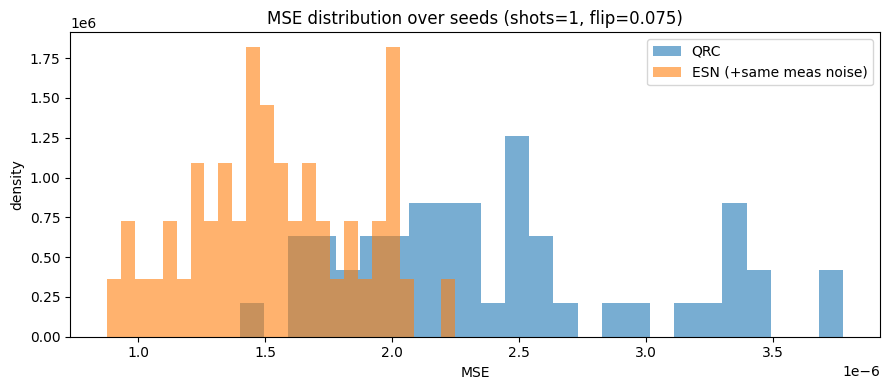

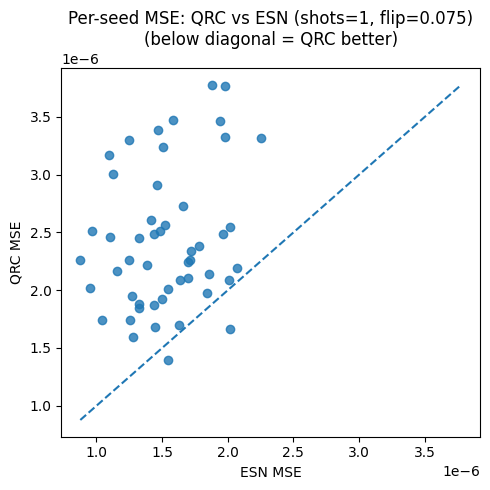

In [ ]:
# ===== 実行 =====
seeds = np.arange(50) + 100  # 例：50 seeds
(q_mse, q_corr), (e_mse, e_corr) = seed_sweep_qrc_vs_esn(
    x_series, seeds,
    N=100, start_t=1000, T=1000,
    shots=1, flip_p=0.075,
    prob_map="affine",
)

print("=== QRC ===")
print("MSE:", summarize(q_mse))
print("Corr:", summarize(q_corr))

print("\n=== ESN (+same measurement noise) ===")
print("MSE:", summarize(e_mse))
print("Corr:", summarize(e_corr))

print("\n=== Paired test (per-seed) ===")
print(paired_tests(q_mse, e_mse))

plot_overlaid_hist(q_mse, e_mse, title="MSE distribution over seeds (shots=1, flip=0.075)")
plot_scatter(q_mse, e_mse, title="Per-seed MSE: QRC vs ESN (shots=1, flip=0.075)")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# QRC: out_prob（平均版）で状態列 S(T,M) を作る
#  ※あなたの "simulate_qrc_states_sampled01" と同じ内部回路で、
#    ⑧の out_prob をそのまま使い、shots/flipを使わない
# -----------------------------
def simulate_qrc_states_meanprob(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U10: np.ndarray,            # (T,10)
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: np.ndarray | None = None,   # (10,M)
    Win_scale: float = 1.0,
    carry_state: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    U10 = np.asarray(U10, float)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError("U10 must be (T,10)")
    T = U10.shape[0]
    M = 12 * N

    rng = np.random.default_rng(seed)

    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(10, M)) * (float(Win_scale) / np.sqrt(10.0))
    else:
        Win = np.asarray(Win, float)
        if Win.shape != (10, M):
            raise ValueError(f"Win must be (10,{M})")

    x_state = np.zeros(M, dtype=float)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # 入力 10次元→M次元
        u_vec = U10[t] @ Win
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ① 確率注入
        p = np.clip(x_state, 0.0, 1.0)      # 無励起確率
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # ②〜⑤ ネットワーク
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / sqrt2

        # ⑧ out_prob（安全版：overflow回避）
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        S[t] = out_prob

        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    return S, x_state


# -----------------------------
# 統計＆描画ユーティリティ
# -----------------------------
def summarize(arr):
    arr = np.asarray(arr, float)
    return {
        "mean": float(np.mean(arr)),
        "std":  float(np.std(arr, ddof=1)),
        "min":  float(np.min(arr)),
        "max":  float(np.max(arr)),
    }

def paired_test(a, b):
    # b - a の平均が正なら「aが良い（MSEが小さい）」に相当するよう注意
    a = np.asarray(a, float); b = np.asarray(b, float)
    diff = b - a
    t, p = stats.ttest_rel(b, a)
    dz = float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-12))
    return {
        "mean_diff(b-a)": float(np.mean(diff)),
        "std_diff": float(np.std(diff, ddof=1)),
        "t_stat": float(t),
        "p_two_sided": float(p),
        "cohens_dz": dz,
        "frac_a_better": float(np.mean(a < b)),
    }

def plot_hist_overlay(series_dict, title, xlabel="MSE"):
    plt.figure(figsize=(10,4))
    for name, arr in series_dict.items():
        plt.hist(arr, bins=25, alpha=0.55, density=True, label=name)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_scatter_xy(x, y, title, xlabel, ylabel):
    x = np.asarray(x, float); y = np.asarray(y, float)
    plt.figure(figsize=(5,5))
    plt.scatter(x, y, alpha=0.8)
    mn = min(np.min(x), np.min(y))
    mx = max(np.max(x), np.max(y))
    plt.plot([mn,mx],[mn,mx],"--")
    plt.title(title + "\n(below diagonal means y < x)")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


# -----------------------------
# 4本同時 seed sweep
# -----------------------------
def sweep_4ways(
    x_series,
    seeds,
    *,
    N=100,
    start_t=1000,
    T=1000,
    ridge=1e-2,
    # QRC params
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    norm_const=1.0, sign_mode="plus", input_mode="scale",
    Win_scale_qrc=1.0, carry_state=True,
    shots=1, flip_p=0.075,
    # ESN params
    spectral_radius=0.9, input_scale_esn=0.5, leak_rate=1.0, bias_scale=0.1,
    prob_map="affine", sigmoid_k=1.0,
):
    U10, Y = make_window10_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    mse_q_mean, corr_q_mean = [], []
    mse_q_samp, corr_q_samp = [], []

    mse_e_cont, corr_e_cont = [], []
    mse_e_samp, corr_e_samp = [], []

    for sd in seeds:
        sd = int(sd)

        # --- QRC meanprob ---
        S_q_mean, _ = simulate_qrc_states_meanprob(
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            U10=U10,
            seed=sd,
            norm_const=norm_const,
            sign_mode=sign_mode,
            input_mode=input_mode,
            Win=None,
            Win_scale=Win_scale_qrc,
            carry_state=carry_state,
        )
        w, b = fit_readout_ridge(S_q_mean, Y, ridge=ridge)
        Yhat = predict_readout(S_q_mean, w, b)
        mse, corr = mse_corr(Y, Yhat)
        mse_q_mean.append(mse); corr_q_mean.append(corr)

        # --- QRC sampled01+flip ---
        S_q_samp, _ = simulate_qrc_states_sampled01(
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            U10=U10,
            seed=sd,
            norm_const=norm_const,
            sign_mode=sign_mode,
            input_mode=input_mode,
            Win=None,
            Win_scale=Win_scale_qrc,
            carry_state=carry_state,
            shots=shots,
            flip_p=flip_p,
        )
        w, b = fit_readout_ridge(S_q_samp, Y, ridge=ridge)
        Yhat = predict_readout(S_q_samp, w, b)
        mse, corr = mse_corr(Y, Yhat)
        mse_q_samp.append(mse); corr_q_samp.append(corr)

        # --- ESN continuous ---
        S_e_cont, _ = simulate_esn_states_tanh(
            M=M, U10=U10,
            seed=sd,
            spectral_radius=spectral_radius,
            input_scale=input_scale_esn,
            leak_rate=leak_rate,
            bias_scale=bias_scale,
        )
        w, b = fit_readout_ridge(S_e_cont, Y, ridge=ridge)
        Yhat = predict_readout(S_e_cont, w, b)
        mse, corr = mse_corr(Y, Yhat)
        mse_e_cont.append(mse); corr_e_cont.append(corr)

        # --- ESN sampled01+flip (same measurement noise) ---
        S_e_samp, _ = simulate_esn_states_sampled01(
            M=M, U10=U10,
            seed=sd,
            spectral_radius=spectral_radius,
            input_scale=input_scale_esn,
            leak_rate=leak_rate,
            bias_scale=bias_scale,
            shots=shots,
            flip_p=flip_p,
            prob_map=prob_map,
            sigmoid_k=sigmoid_k,
        )
        w, b = fit_readout_ridge(S_e_samp, Y, ridge=ridge)
        Yhat = predict_readout(S_e_samp, w, b)
        mse, corr = mse_corr(Y, Yhat)
        mse_e_samp.append(mse); corr_e_samp.append(corr)

    out = {
        "QRC_mean": (np.array(mse_q_mean), np.array(corr_q_mean)),
        "QRC_samp": (np.array(mse_q_samp), np.array(corr_q_samp)),
        "ESN_cont": (np.array(mse_e_cont), np.array(corr_e_cont)),
        "ESN_samp": (np.array(mse_e_samp), np.array(corr_e_samp)),
    }
    return out

=== SUMMARY (MSE) ===
QRC mean : {'mean': 0.00012779654944340978, 'std': 3.4082346551281836e-05, 'min': 6.538957876867873e-05, 'max': 0.00027099651183533797}
QRC samp : {'mean': 2.4251561254565292e-06, 'std': 6.071272358433766e-07, 'min': 1.399637788545153e-06, 'max': 3.7763440477213307e-06}
ESN cont : {'mean': 9.245907175612009e-06, 'std': 2.884217978455179e-06, 'min': 5.058007649975021e-06, 'max': 1.6552031531033427e-05}
ESN samp : {'mean': 1.5332203406509038e-06, 'std': 3.3160744014256414e-07, 'min': 8.768055997979382e-07, 'max': 2.2494882301849917e-06}

=== SUMMARY (Corr) ===
QRC mean : {'mean': 0.9999989505103806, 'std': 2.799233517379377e-07, 'min': 0.9999977743345323, 'max': 0.9999994629837986}
QRC samp : {'mean': 0.9999999803008508, 'std': 4.942864996688611e-09, 'min': 0.999999969241006, 'max': 0.9999999886501785}
ESN cont : {'mean': 0.9999999240210512, 'std': 2.370122581713058e-08, 'min': 0.9999998639823477, 'max': 0.9999999584353668}
ESN samp : {'mean': 0.9999999874418544, 's

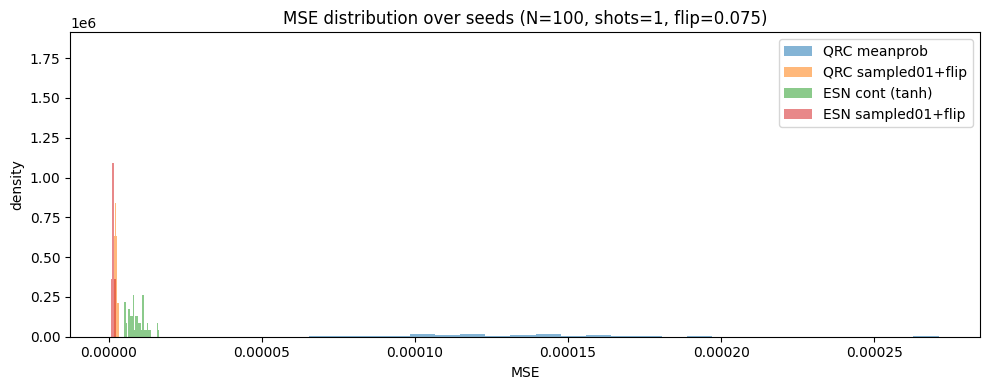


=== ΔMSE (measured - baseline) ===
QRC ΔMSE: {'mean': -0.00012537139331795326, 'std': 3.4058825663536387e-05, 'min': -0.0002687369181205699, 'max': -6.341148850507085e-05}
ESN ΔMSE: {'mean': -7.712686834961103e-06, 'std': 2.825551696008406e-06, 'min': -1.545046616125316e-05, 'max': -3.473963683565008e-06}


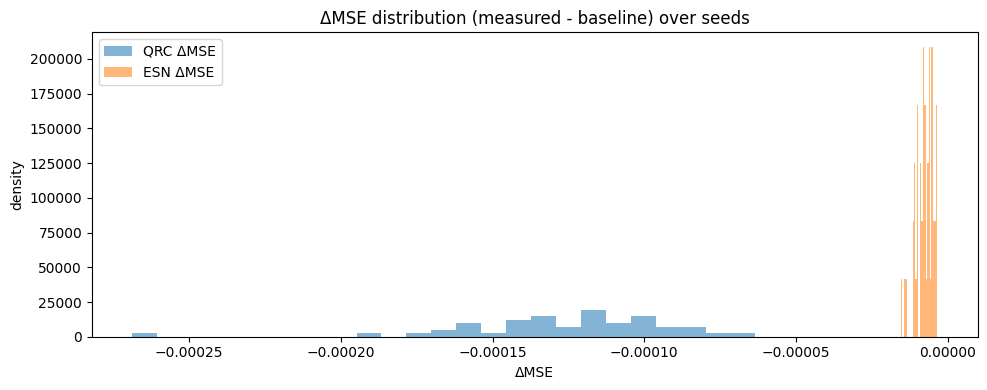


=== Paired test: baseline vs measured (MSE) ===
QRC: meanprob vs sampled01: {'mean_diff(b-a)': -0.00012537139331795326, 'std_diff': 3.4058825663536387e-05, 't_stat': -26.02877834300696, 'p_two_sided': 2.3919197529219533e-30, 'cohens_dz': -3.6810250263899054, 'frac_a_better': 0.0}
ESN: cont    vs sampled01: {'mean_diff(b-a)': -7.712686834961103e-06, 'std_diff': 2.825551696008406e-06, 't_stat': -19.3013391681119, 'p_two_sided': 1.5189966255305743e-24, 'cohens_dz': -2.7296205963019697, 'frac_a_better': 0.0}

=== Paired test: QRC measured vs ESN measured (MSE) ===
{'mean_diff(b-a)': -8.919357848056256e-07, 'std_diff': 6.210013133315634e-07, 't_stat': -10.156079033640701, 'p_two_sided': 1.2008709447293797e-13, 'cohens_dz': -1.4362841581387256, 'frac_a_better': 0.04}


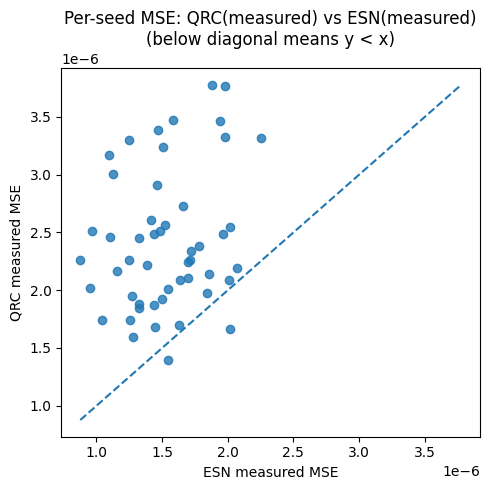

In [ ]:
# ==============================
# 実行
# ==============================
seeds = np.arange(50) + 100
out = sweep_4ways(
    x_series, seeds,
    N=100, start_t=1000, T=1000,
    shots=1, flip_p=0.075,
    prob_map="affine",
)

m_q_mean, c_q_mean = out["QRC_mean"]
m_q_samp, c_q_samp = out["QRC_samp"]
m_e_cont, c_e_cont = out["ESN_cont"]
m_e_samp, c_e_samp = out["ESN_samp"]

print("=== SUMMARY (MSE) ===")
print("QRC mean :", summarize(m_q_mean))
print("QRC samp :", summarize(m_q_samp))
print("ESN cont :", summarize(m_e_cont))
print("ESN samp :", summarize(m_e_samp))

print("\n=== SUMMARY (Corr) ===")
print("QRC mean :", summarize(c_q_mean))
print("QRC samp :", summarize(c_q_samp))
print("ESN cont :", summarize(c_e_cont))
print("ESN samp :", summarize(c_e_samp))

# 分布図（MSE）
plot_hist_overlay(
    {
        "QRC meanprob": m_q_mean,
        "QRC sampled01+flip": m_q_samp,
        "ESN cont (tanh)": m_e_cont,
        "ESN sampled01+flip": m_e_samp,
    },
    title=f"MSE distribution over seeds (N={100}, shots=1, flip=0.075)"
)

# 改善量 ΔMSE = (測定後 - 測定前)
dq = m_q_samp - m_q_mean   # QRCで測定を入れたらどう動いたか（負なら改善）
de = m_e_samp - m_e_cont   # ESNで測定を入れたらどう動いたか

print("\n=== ΔMSE (measured - baseline) ===")
print("QRC ΔMSE:", summarize(dq))
print("ESN ΔMSE:", summarize(de))

plot_hist_overlay(
    {"QRC ΔMSE": dq, "ESN ΔMSE": de},
    title="ΔMSE distribution (measured - baseline) over seeds",
    xlabel="ΔMSE"
)

# paired test: baseline vs measured
print("\n=== Paired test: baseline vs measured (MSE) ===")
print("QRC: meanprob vs sampled01:", paired_test(m_q_mean, m_q_samp))
print("ESN: cont    vs sampled01:", paired_test(m_e_cont, m_e_samp))

# 参考：QRC measured と ESN measured の直接比較（あなたが今やっている比較）
print("\n=== Paired test: QRC measured vs ESN measured (MSE) ===")
print(paired_test(m_q_samp, m_e_samp))

# 散布図：measured同士
plot_scatter_xy(
    m_e_samp, m_q_samp,
    title="Per-seed MSE: QRC(measured) vs ESN(measured)",
    xlabel="ESN measured MSE",
    ylabel="QRC measured MSE",
)

**1000ステップ予測**

In [ ]:
def make_window10_dataset(x_series: np.ndarray, start_t: int, T: int):
    """
    入力:  U10[k] = [x(t-9)..x(t)],  t = start_t + k
    教師:  Y[k]   = x(t+1)
    """
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 9:
        raise ValueError("start_t must be >= 9")
    if start_t + T + 1000 > len(x):
        raise ValueError("range out of x_series (need t+1)")

    U10 = np.vstack([x[t-9:t+1] for t in range(start_t, start_t + T)])  # (T,10)
    Y = x[start_t + 1000 : start_t + T + 1000]                                # (T,)
    return U10, Y

def lorenz_f(XYZ):
    X, Y, Z = XYZ
    return np.array([10.0*(Y - X), (X*(28.0 - Z) - Y), (X * Y - 8.0/3*Z)])

def lorenz_x_RK(t):
    XYZ = np.array([0.5, 0.1, 0.2])
    dt = 0.01
    Xset = [XYZ[0]]
    for _ in range(t + 1000):  # burn-in 1000
        k1 = lorenz_f(XYZ)
        k2 = lorenz_f(XYZ + dt/2 * k1)
        k3 = lorenz_f(XYZ + dt/2 * k2)
        k4 = lorenz_f(XYZ + dt * k3)
        XYZ += dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        Xset.append(XYZ[0])
    return np.array(Xset[1000:])  # X(t) 連続値


import matplotlib.pyplot as plt
import numpy as np

def plot_timeseries_compare(y_true, y_pred, *, start=0, length=300, title=None):
    """
    y_true, y_pred: 1D arrays (same length)
    start: プロット開始インデックス
    length: 表示点数
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    assert y_true.shape == y_pred.shape

    end = min(start + length, y_true.size)
    t = np.arange(start, end)

    plt.figure(figsize=(12, 4))
    plt.plot(t, y_true[start:end], label="True", lw=2)
    plt.plot(t, y_pred[start:end], label="Predicted", lw=1.5, alpha=0.8)
    plt.xlabel("time index")
    plt.ylabel("x")
    plt.legend()
    if title is not None:
        plt.title(title)
    plt.tight_layout()
    plt.show()

MSE= 55.42694469867737 Corr= 0.31364268153650154


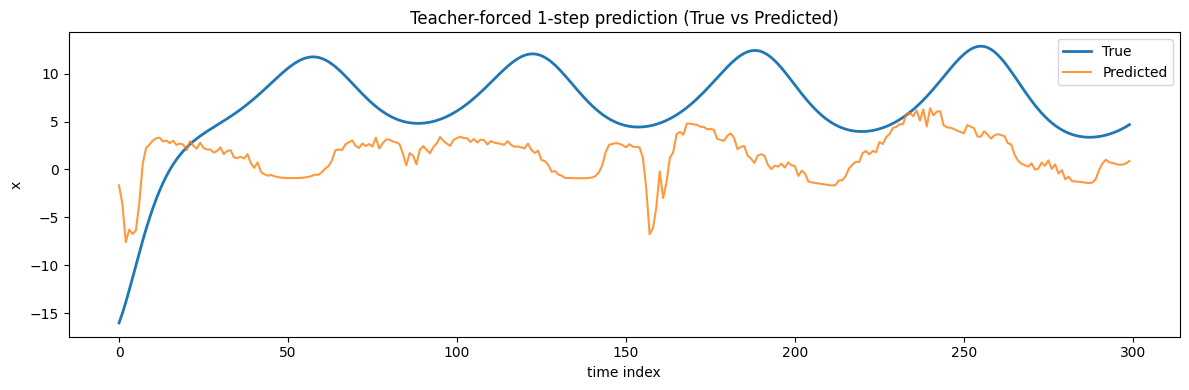

In [ ]:
# Lorenz
x_series = lorenz_x_RK(6000)

# データ（例：t=1000から1000ステップ分）
U10, Y = make_window10_dataset(x_series, start_t=1000, T=1000)

# 学習＋予測
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=1,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 52.21342660636181 Corr= 0.3881313916271576


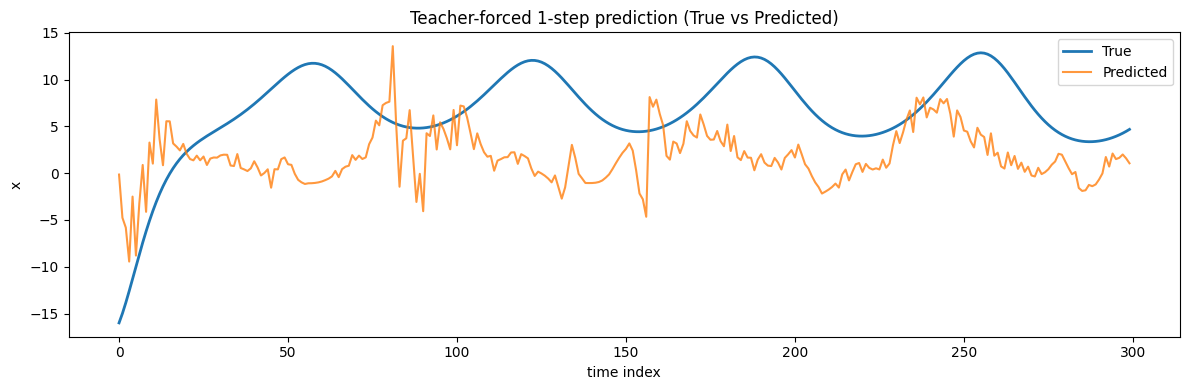

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=2,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 50.47886256209901 Corr= 0.4229208642256536


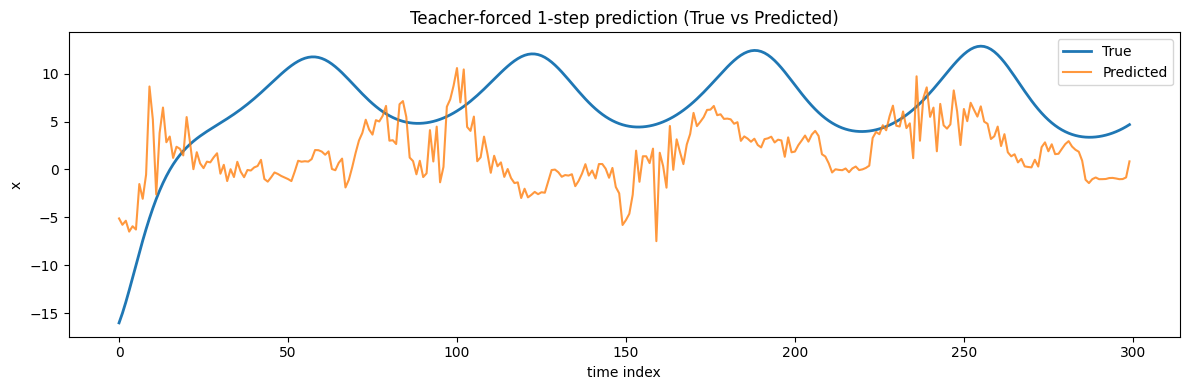

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=3,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 47.35377508596546 Corr= 0.4792680515596


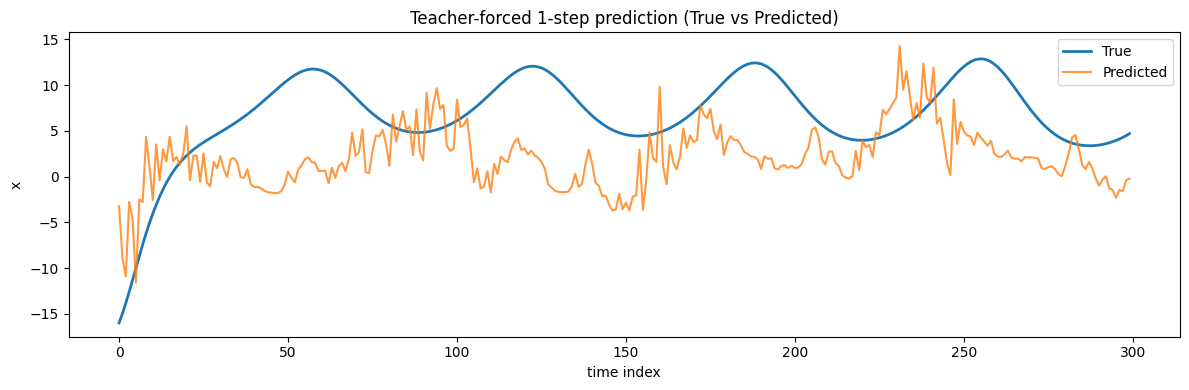

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=4,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 12.720227303731354 Corr= 0.8905991097627824


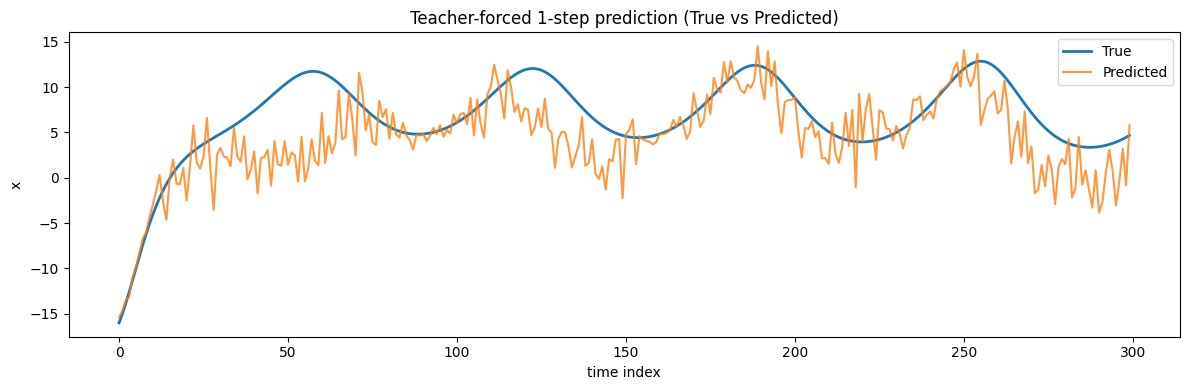

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=50,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 3.4555786301098395 Corr= 0.9716821968423406


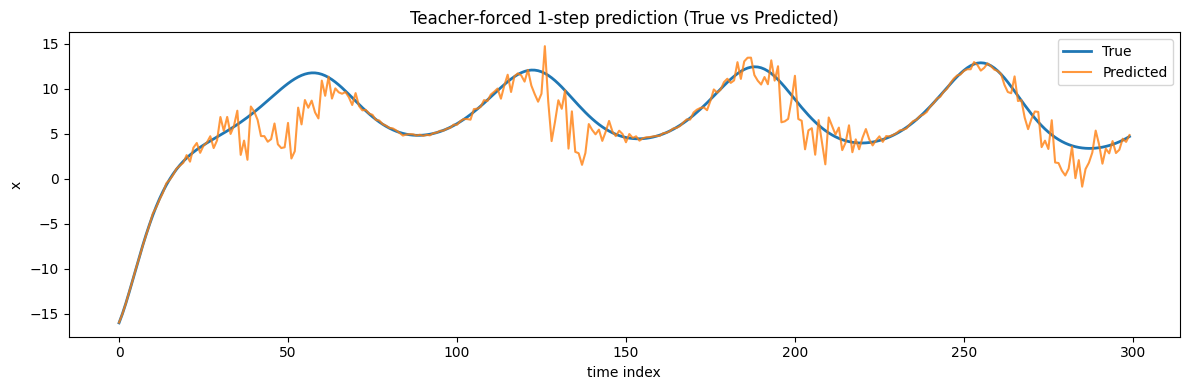

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

MSE= 2.120591963187371 Corr= 0.9828311724335846


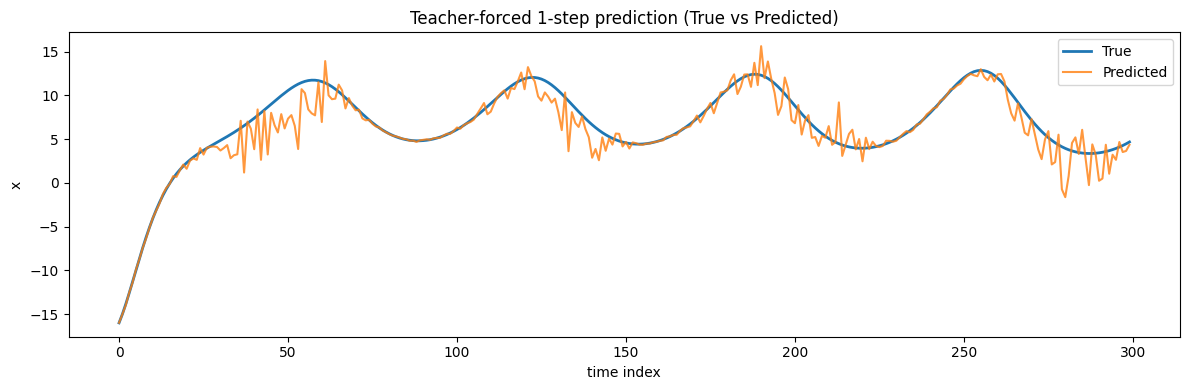

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=2,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

/tmp/ipython-input-1272298813.py:134: RuntimeWarning: overflow encountered in exp
  p0_like = coef * np.exp(-np.abs(fin) ** 2) * np.exp((np.tanh(squeeze_r)) * fin ** 2)
/tmp/ipython-input-1272298813.py:134: RuntimeWarning: invalid value encountered in multiply
  p0_like = coef * np.exp(-np.abs(fin) ** 2) * np.exp((np.tanh(squeeze_r)) * fin ** 2)


MSE= nan Corr= nan


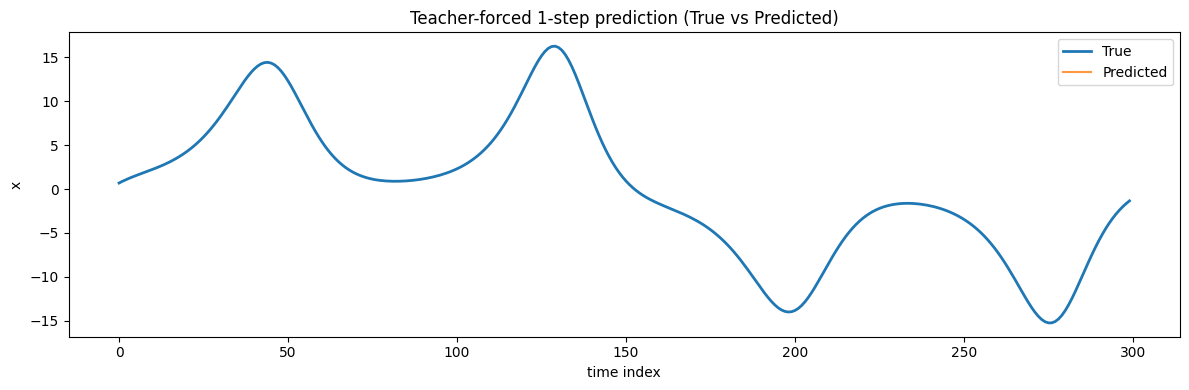

In [ ]:
w, b, y_hat, S, xT = simulate_and_fit_one_pass_window10(
    N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10, Y=Y,
    ridge=1e-2,
    seed=48,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

mse = np.mean((y_hat - Y)**2)
corr = np.corrcoef(y_hat, Y)[0,1]
print("MSE=", mse, "Corr=", corr)

plot_timeseries_compare(
    Y, y_hat,
    start=0,
    length=300,
    title="Teacher-forced 1-step prediction (True vs Predicted)"
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 10点窓入力の作成（教師は x(t+1)）
# -----------------------------
def make_window10_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    """
    入力:  U10[k] = [x(t-9)..x(t)],  t = start_t + k
    教師:  Y[k]   = x(t+1)
    """
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 9:
        raise ValueError("start_t must be >= 9")
    if start_t + T + 1 > len(x):
        raise ValueError("range out of x_series (need t+1)")

    U10 = np.vstack([x[t-9:t+1] for t in range(start_t, start_t + T)])  # (T,10)
    Y  = x[start_t + 1 : start_t + T + 1]                                # (T,)
    return U10, Y


# -----------------------------
# free-run（自己回帰）: 予測値を窓に戻して回す
# -----------------------------
def free_run_window10(
    *,
    x_init_window10: np.ndarray,   # shape (10,)  初期の [x(t-9)..x(t)]（ここだけ真値でOK）
    steps: int,                    # 何ステップ未来まで free-run するか
    N: int, alpha: float, beta: float, squeeze_r: float,
    w: np.ndarray, b: float,
    Win: np.ndarray,               # simulate_and_fit_one_pass_window10 で使った同じWin
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale: float = 1.0,        # Winを外部から渡すなら通常不要
    carry_state: bool = True,
    x0: np.ndarray | None = None,  # リザバー内部状態(無励起確率)の初期値。Noneならゼロ
):
    """
    返り値:
      preds: (steps,) free-run予測列（x(t+1), x(t+2), ...）
      windows: (steps+1, 10)  窓の推移（デバッグ用）
    """
    xw = np.asarray(x_init_window10, float).reshape(-1)
    if xw.size != 10:
        raise ValueError("x_init_window10 must have length 10.")

    M = 12 * N
    w = np.asarray(w, float).reshape(-1)
    if w.size != M:
        raise ValueError(f"w must have length M={M}, got {w.size}")
    Win = np.asarray(Win, float)
    if Win.shape != (10, M):
        raise ValueError(f"Win must be shape (10,{M}), got {Win.shape}")

    # --- リザバー内部状態（無励起確率）
    if x0 is None:
        x_state = np.zeros(M, dtype=float)
    else:
        x_state = np.clip(np.asarray(x0, float).reshape(-1), 0.0, 1.0)
        if x_state.size != M:
            raise ValueError(f"x0 must have length {M}, got {x_state.size}")

    rng = np.random.default_rng(seed)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b_):
        return ((a + b_) / sqrt2, (-a + b_) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b_ = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b_)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b_):
        return ((a + np.sqrt(2.0) * b_) / sqrt3, ((-np.sqrt(2.0)) * a + b_) / sqrt3)

    preds = np.empty(steps, dtype=float)
    windows = np.empty((steps + 1, 10), dtype=float)
    windows[0] = xw.copy()

    for k in range(steps):
        # 10点窓 → M次元入力 u_vec
        u_vec = xw @ Win  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ① 確率注入（無励起確率 x_state）
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # ②〜⑤ 干渉ネットワーク
        pairs_adj = [(i, i + 1) for i in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        # ⑦ 合成
        fin = (wnet + u_vec) / sqrt2

        # ⑧ 検出確率 out_prob（サンプルしない）
        coef = 1.0 / np.cosh(squeeze_r)
        p0_like = coef * np.exp(-np.abs(fin) ** 2) * np.exp((np.tanh(squeeze_r)) * fin ** 2)
        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        # 読出し：x(t+1) 予測
        y_next = float(out_prob @ w + b)
        preds[k] = y_next

        # 窓を更新（真値ではなく予測値を入れる）
        xw = np.concatenate([xw[1:], [y_next]])
        windows[k + 1] = xw

        # 状態更新（無励起確率）
        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    return preds, windows


# -----------------------------
# 比較プロット（真値 vs 予測）
# -----------------------------
def plot_free_run(true_future, pred_future, *, start=0, length=300, title=None):
    true_future = np.asarray(true_future).reshape(-1)
    pred_future = np.asarray(pred_future).reshape(-1)
    end = min(start + length, true_future.size, pred_future.size)
    t = np.arange(start, end)

    plt.figure(figsize=(12, 4))
    plt.plot(t, true_future[start:end], label="True", lw=2)
    plt.plot(t, pred_future[start:end], label="Free-run pred", lw=1.5, alpha=0.85)
    plt.xlabel("step")
    plt.ylabel("x")
    plt.legend()
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

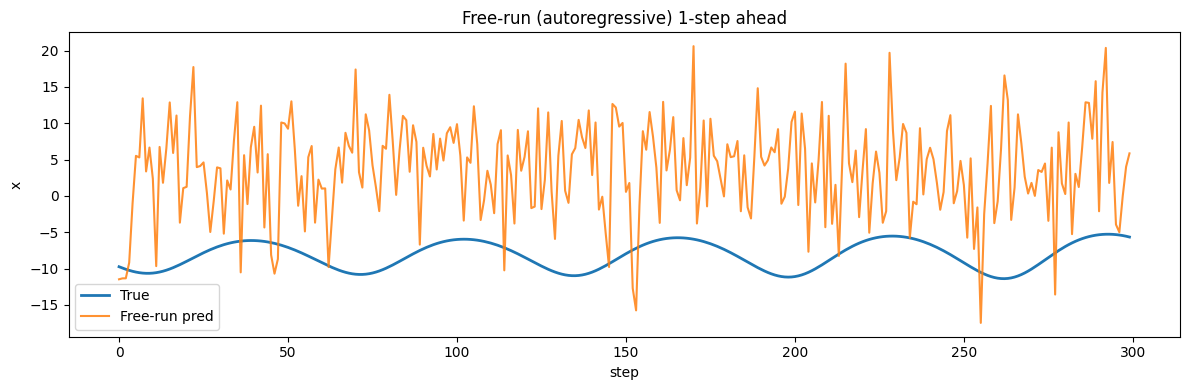

In [ ]:
# Lorenz
x_series = lorenz_x_RK(6000)

# ---- 学習区間 ----
train_start = 1000
T_train = 2000
U10_tr, Y_tr = make_window10_dataset_next(x_series, start_t=train_start, T=T_train)

# 学習（あなたの既存関数）
w, b, y_hat_tr, S_tr, xT = simulate_and_fit_one_pass_window10(
    N=10,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10_tr, Y=Y_tr,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=None, Win_scale=1.0,
    carry_state=True
)

# ここが重要：free-run で「同じWin」を使うために Win を外で保持したいなら、
# simulate_and_fit_one_pass_window10 を「Winも返す」ように改造するのがベストです。
# もし改造してない場合は、Winを別途生成して学習と予測で共有してください。
# 例：Winを自分で先に作って渡す:
#   Win = np.random.default_rng(43).uniform(-1,1,size=(10,12*N))*1.0
#   ...学習時 Win=Win を渡す
# という形にしてください。

# 例：学習時にも予測時にも同じ Win を使う（推奨）
N = 20
M = 12*N
Win_shared = np.random.default_rng(43).uniform(-1.0, 1.0, size=(10, M)) * 1.0

w, b, y_hat_tr, S_tr, xT = simulate_and_fit_one_pass_window10(
    N=N,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    U10=U10_tr, Y=Y_tr,
    ridge=1e-2,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win=Win_shared, Win_scale=1.0,
    carry_state=True
)

# ---- free-run開始点 ----
# 初期窓は真値で用意（ここから先は真値を使わない）
t0 = train_start + T_train  # 学習区間の直後から予測する例
x_init_window10 = x_series[t0-9:t0+1]   # [x(t0-9)..x(t0)]

steps = 500
preds_free, _ = free_run_window10(
    x_init_window10=x_init_window10,
    steps=steps,
    N=N, alpha=1.0, beta=0.7, squeeze_r=0.3,
    w=w, b=b,
    Win=Win_shared,
    seed=43,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    carry_state=True,
    x0=None
)

# 真値（比較用）: x(t0+1) ... x(t0+steps)
true_future = x_series[t0+1 : t0+1+steps]

plot_free_run(true_future, preds_free, length=300, title="Free-run (autoregressive) 1-step ahead")